#Dataset Description

Classification goal : classifying wether the income of a person higher or less than 50K depending on dataset features values

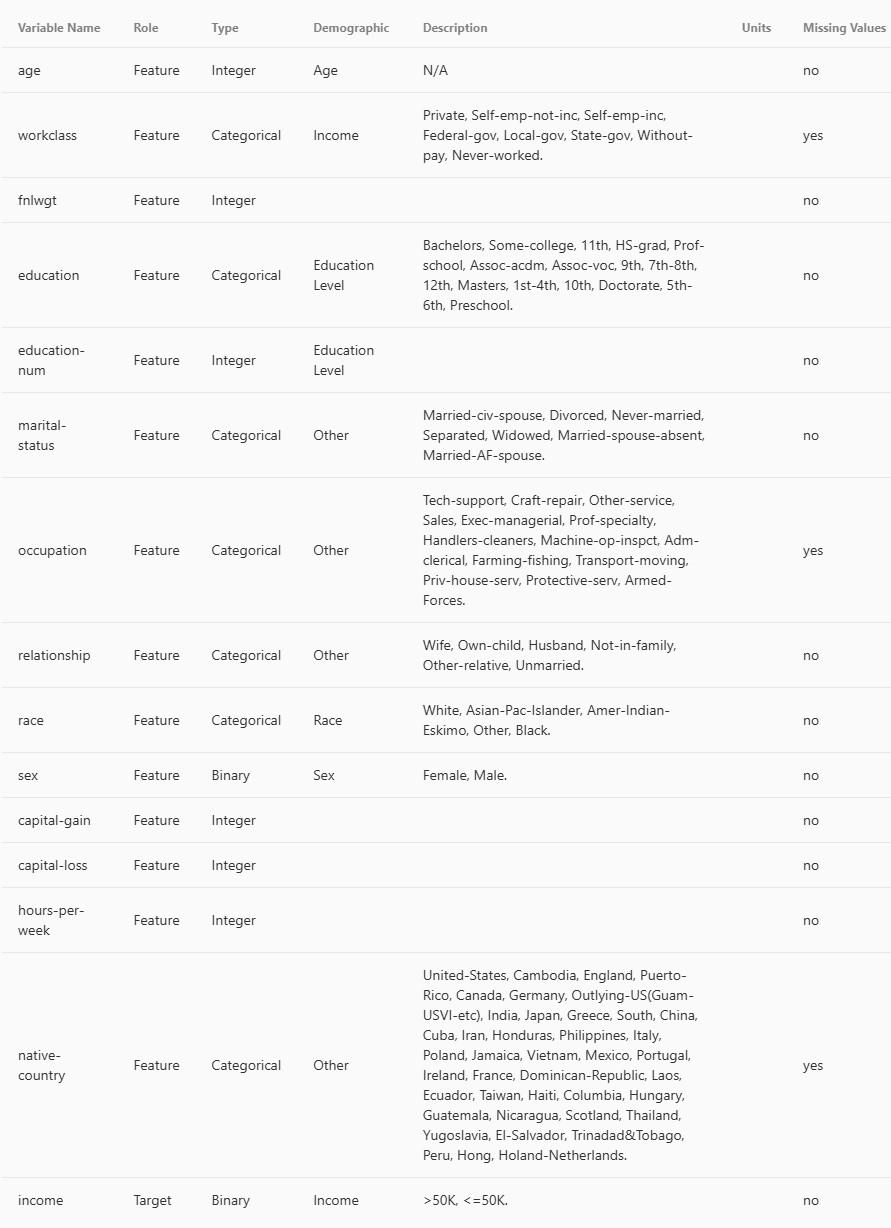

#Documentation


---



- I calculate the correlation on a later section but i transfer the block that drop  the fnlwgt column since its correlation with the target was too low and didn't seem useful for training or analysis.

- I reviewed the unique values in each column to spot any potential issues like missing  values.

- I found ? values in occupation, workclass, and native-country and counted the records affected and i did drop them.

- number of records I dropped with ? values was 3,620 records .

- The dataset become 45,222 rows and 14 columns.



---




Why target Encoding?
i thought it was  better than one hot encoding because it keep the same df size (only gender been encoded to 0 1 because it is a binary feature).

Dataset i will continue with :
- df_encoded = df.copy()

- I encode the gender column into numeric form, mapping 'Male' to 1 and 'Female' to 0 .

- I encode these categorical columns ('workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country') into target encoding  (numeric representations based on their correlation with the target).

- The target column (income) to numeric, mapping '>50K' to 1 and '<=50K' to 0, making it binary for classification.









---



- heatmap visualization

- I  printed the correlations of all features with the target, sorting them in descending order. The highest correlation  features with the target were relationship, marital-status, and education, with correlations around 0.45, while native-country and race had the lowest correlations, below 0.10.

- education , education-num = 0.91
- marital-status , relationship = 0.97

i drop one of each pairs by testing . i keep the one who give highest accuracy .



---





---



Here are the 14 feature-engineered columns:

1. **log_capital_gain**
2. **log_capital_loss**
3. **age_hours_interaction**
4. **capital_net**
5. **education_occupation**
6. **gender_relationship**
7. **age_relationship**
8. **relationship_hours_per_week**
9. **age_occupation**
10. **education_hours_per_week**
11. **relationship_marital_status**
12. **education_squared**
13. **relationship_squared**
14. **age_squared**





---



Here is the list of the feature-engineered columns based on the correlations between features (from the heatmap) and short explanations:

1. **education_occupation**: Multiplied because education and occupation had a moderate correlation (0.52).
2. **age_relationship**: Multiplied due to a moderate correlation between age and relationship (0.35).
3. **relationship_marital_status**: Multiplied because relationship and marital-status had a very high correlation (0.97).
4. **gender_relationship**: Multiplied due to moderate correlation between gender and relationship (0.42).
5. **age_hours_interaction**: Multiplied as age and hours-per-week showed moderate correlation (0.25).
6. **education_hours_per_week**: Multiplied due to moderate correlation between education and hours-per-week (0.25).
7. **age_occupation**: Multiplied due to moderate correlation between age and occupation (0.48).
8. **relationship_hours_per_week**: Multiplied because relationship and hours-per-week showed moderate correlation (0.28).

These interactions were created because of the relatively strong or moderate correlations between the feature pairs with each others (not with the target), They are all test cases .



---



remaining explanations :

9. **capital_net**: Subtracted capital-loss from capital-gain because both are directly related and capture a net financial effect.
10. **log_capital_gain**: Log-transformed capital-gain to reduce skewness and normalize its range.
11. **log_capital_loss**: Log-transformed capital-loss for the same reason, improving the distribution of this feature.
12. **education_squared**: Squared education to capture any potential non-linear relationship between education and other variables.
13. **relationship_squared**: Squared relationship to model potential non-linear effects in relationships.
14. **age_squared**: Squared age to capture non-linear age effects that could impact income in complex ways.

These engineered features was test cases



---



14 FEATURE ENGINEERED COLUMNS CALCULATIONS:  
- log_capital_gain: np.log1p(df_encoded['capital-gain']) Correlation: 0.29


- log_capital_loss: np.log1p(df_encoded['capital-loss']) Correlation: 0.14



- age_hours_interaction: df_encoded['age'] * df_encoded['hours-per-week'] Correlation: 0.32




- capital_net: df_encoded['capital-gain'] - df_encoded['capital-loss'] Correlation: 0.21




- education_occupation: df_encoded['education'] * df_encoded['occupation']
Correlation: 0.40





- gender_relationship: df_encoded['gender'] * df_encoded['relationship'] Correlation: 0.40




- age_relationship: df_encoded['age'] * df_encoded['relationship'] Correlation: 0.45




- relationship_hours_per_week: df_encoded['relationship'] * df_encoded['hours-per-week'] Correlation: 0.46




- age_occupation: df_encoded['age'] * df_encoded['occupation'] Correlation: 0.40



- education_hours_per_week: df_encoded['education'] * df_encoded['hours-per-week']Correlation: 0.39




- relationship_marital_status: df_encoded['relationship'] * df_encoded['marital-status'] Correlation: 0.45






- education_squared: df_encoded['education'] ** 2 Correlation: 0.35


- relationship_squared: df_encoded['relationship'] ** 2  Correlation: 0.45




- age_squared: df_encoded['age'] ** 2 Correlation: 0.19



---



DROPPED COLUMNS

1. **education_squared**: Redundant, similar correlation to `education`.
2. **relationship_squared**: Redundant, similar correlation to `relationship`.
3. **age_squared**: Low correlation, less useful than `age`.
4. **age_relationship**: Interaction didn’t add significant value beyond other features.
5. **education_hours_per_week**: Redundant interaction, similar to existing features.
6. **relationship_marital_status**: Similar high correlation to `relationship`.
7. **educational-num**: Redundant, mirrors `education`.
8. **relationship**: Dropped as its interaction features were more valuable.
9. **log_capital_loss**: Low correlation with income.
10. **race**: Weak correlation with income.
11. **native-country**: Weak correlation with income.

These were dropped to remove redundancy and focus on more impactful features.



---




PREPARING FOR MODELING :
1. Split the dataset: 85% for training/validation, 15% for testing.
2. Further split training/validation: 70% training, 15% validation.
3. Applied SMOTE on training data to balance class distribution (class 0 initially overrepresented).
4. After SMOTE, both classes (0 and 1) had equal samples (23,808 each).
5. Checked dataset shapes: training set expanded after SMOTE, validation and test sets unchanged.
6. Scaled the training, validation, and test sets using StandardScaler to prepare for Logistic Regression and ANN models.

**Why SMOTE: i tried to use class weights on logreg and RF and this method was better**

- Random thought :  i think the analysis on the data if all was from US and white people will lead to better results bec the count of them is so high that it made me  think the predections will be bias to them .



---



LOGISTIC REGRESSION BEFORE TUNING :

**Validation Set:**
- Accuracy: 0.8096
- Precision: 0.5825
- Recall: 0.8187
- F1-Score: 0.6807
- AUC-ROC: 0.8960

**Test Set:**
- Accuracy: 0.8109
- Precision: 0.5835
- Recall: 0.8275
- F1-Score: 0.6844
- AUC-ROC: 0.9019



 **Confusion Matrices**:
   - Good recall for class 1 (higher income), correctly predicting many true positives.
   - Some false positives and false negatives remain.


**ROC Curves**:
   - Both validation and test sets have AUC-ROC of 0.90, showing strong performance in distinguishing between income classes.

[ Model performance is consistent across validation and test set.]


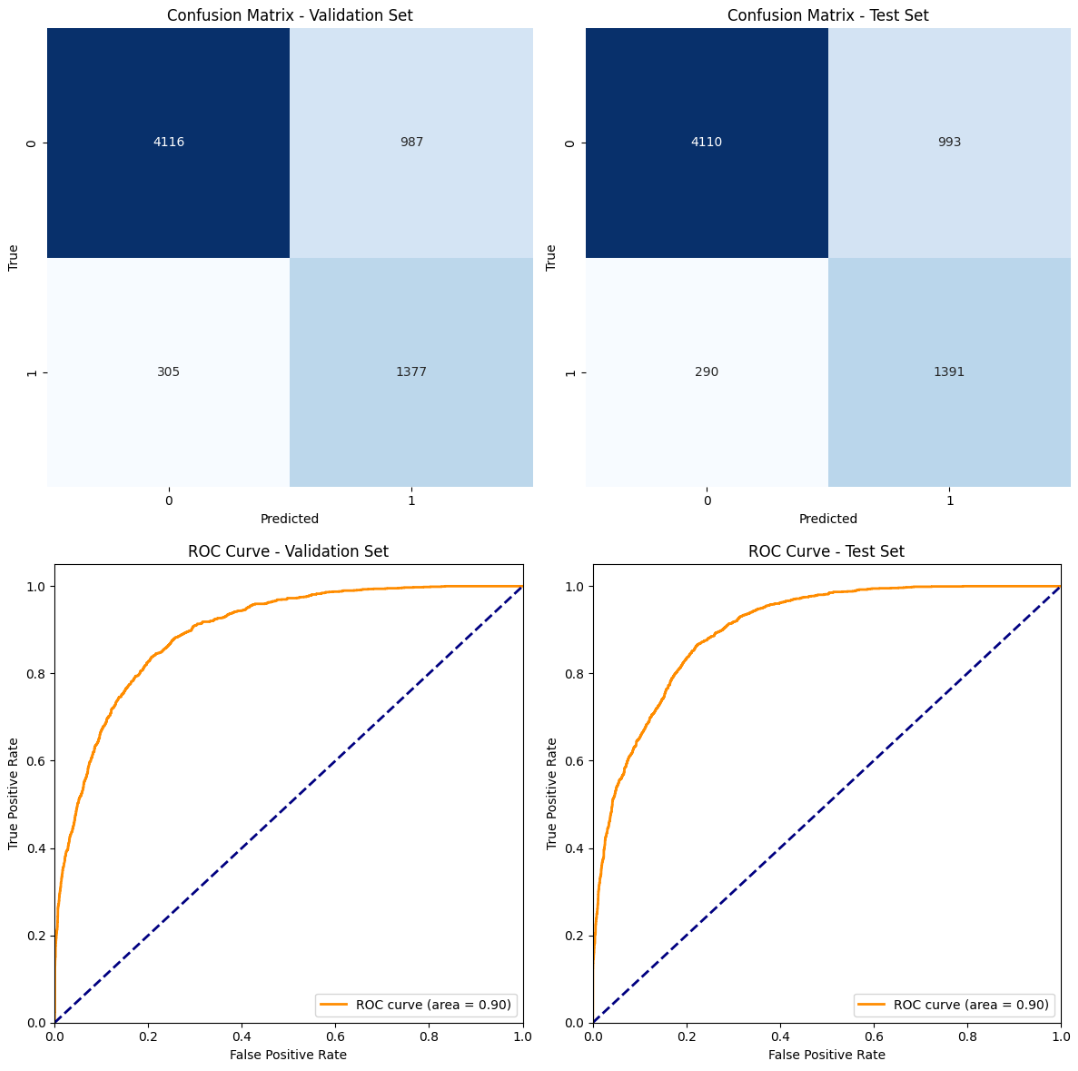



---



 Random Forest model before tuning:

**Validation Set:**
- Accuracy: 0.8360
- Precision: 0.6751
- Recall: 0.6522
- F1-Score: 0.6634
- AUC-ROC: 0.8933

**Test Set:**
- Accuracy: 0.8349
- Precision: 0.6720
- Recall: 0.6520
- F1-Score: 0.6618
- AUC-ROC: 0.8896

The confusion matrices and ROC curves continue to show a consistent performance across both validation and test sets.


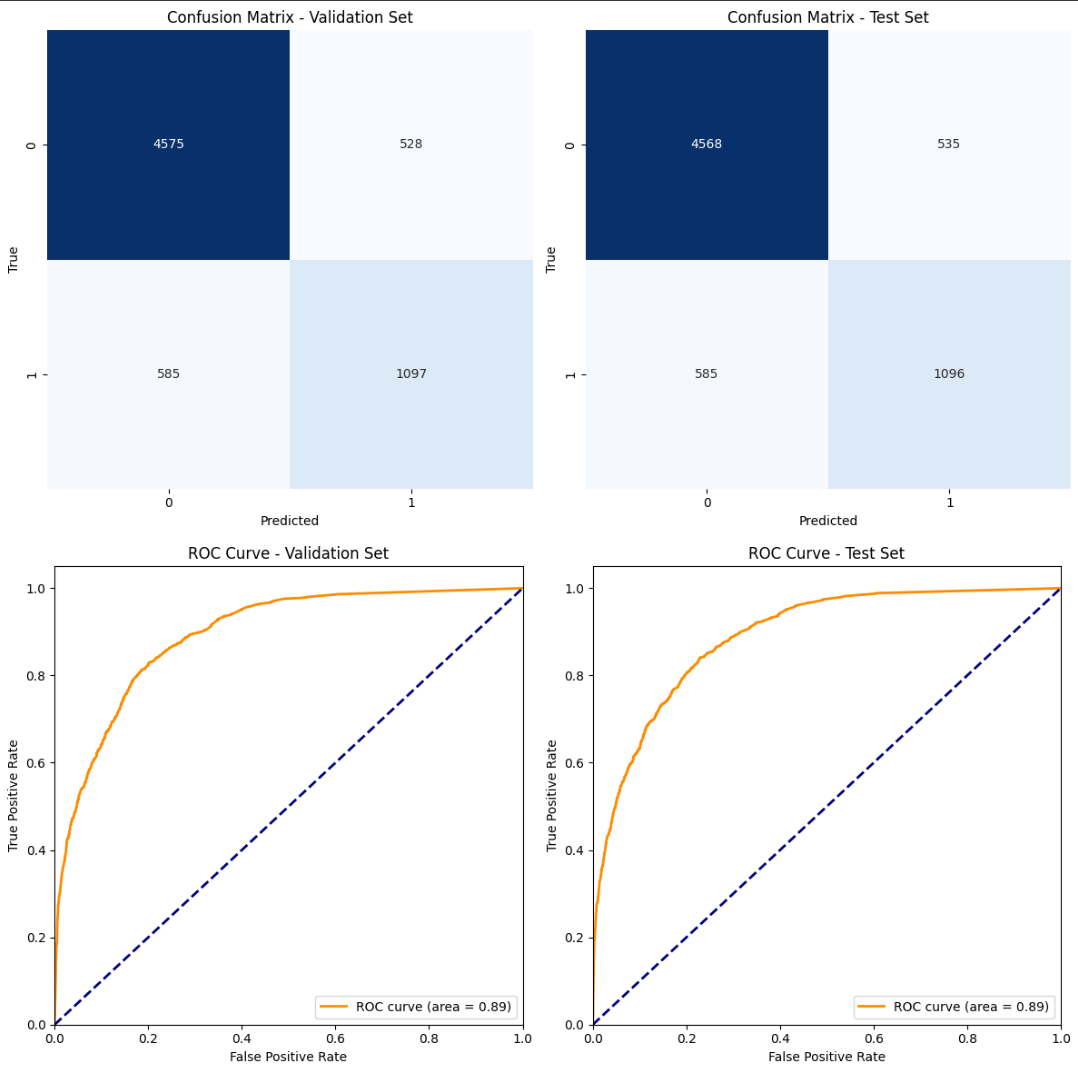



---



Artificial Neural Network (ANN) model before tuning:
at first i did not apply early stopping or dropout the learning curve was as below


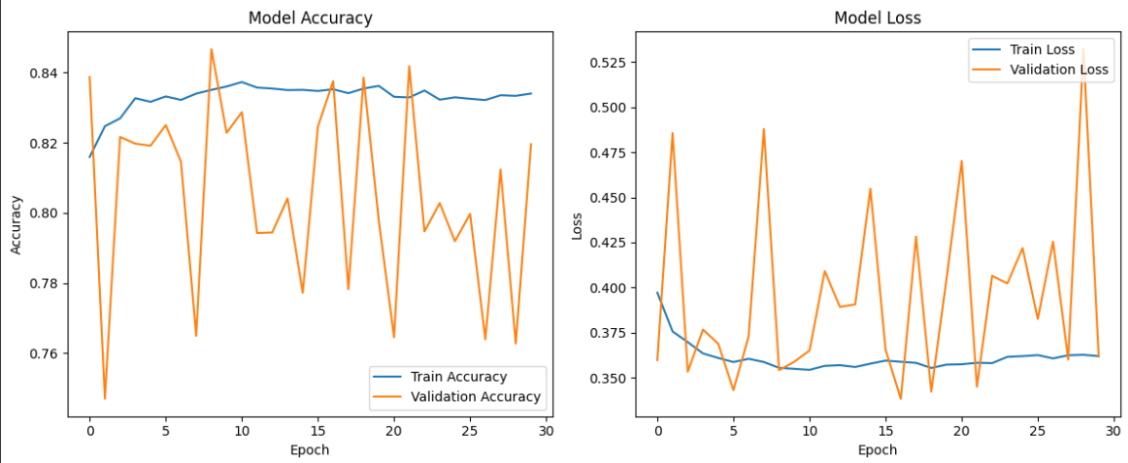


 **Validation Set:**
- **Accuracy**: 0.7959
- **Loss**: 0.3869
- **Confusion Matrix**: Shows that the model has a good recall for both classes, although there are some false positives and negatives.
- **ROC AUC**: 0.90, indicating the model's strong ability to distinguish between the classes.

 **Test Set:**
- **Accuracy**: 0.7958
- **Loss**: 0.3822
- **Confusion Matrix**: Similar to the validation set, with a reasonable balance between true positives and false positives.
- **ROC AUC**: 0.90, showing similar performance on the test set as on the validation set.

 **Training Performance:**
- The model was trained with early stopping to avoid overfitting, stopping when the validation loss stop improving.

The ANN shows good performance across both validation and test sets, with good accuracy and AUC-ROC scores.The dropout layers for performance stability.



```
the learning curve here was the best that i could reach . i try to add
 the parameters before tuning to the random search but also
the learning curve was not good after tuning .
```



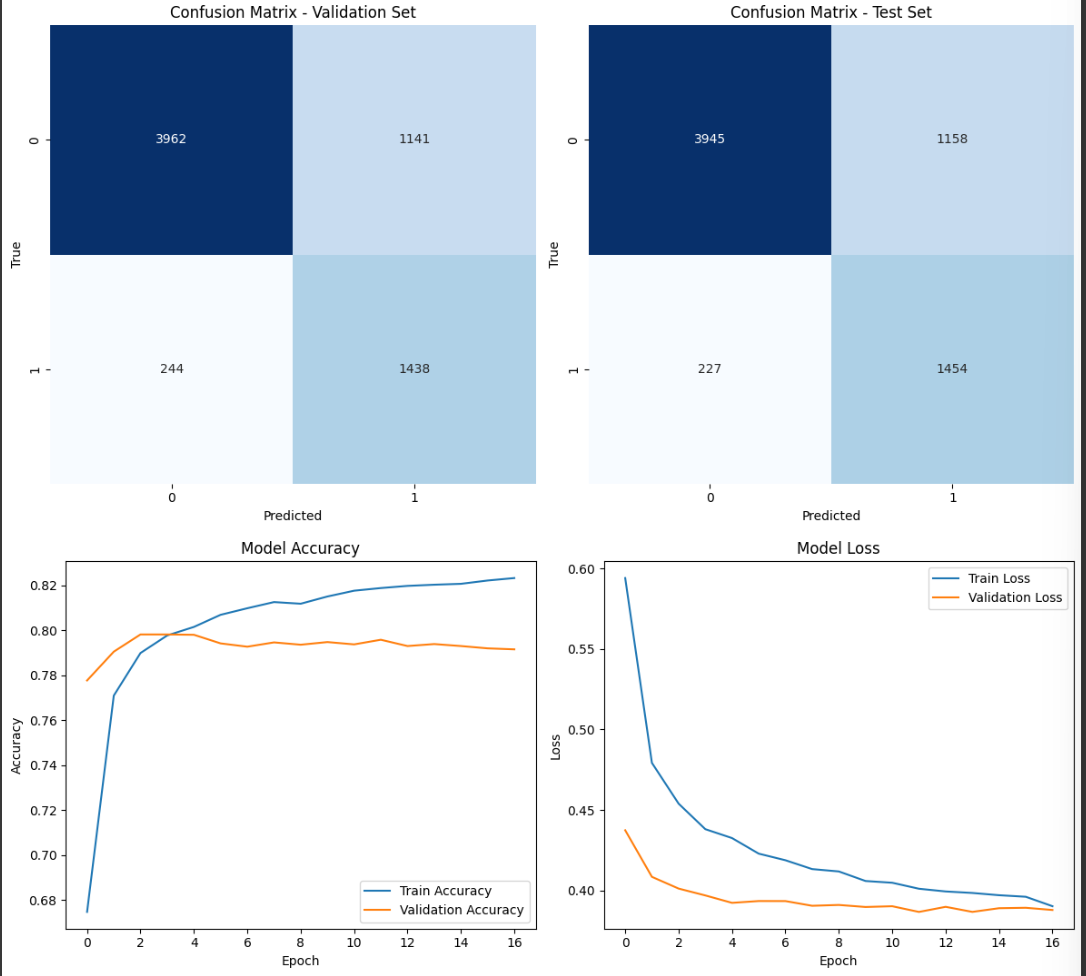

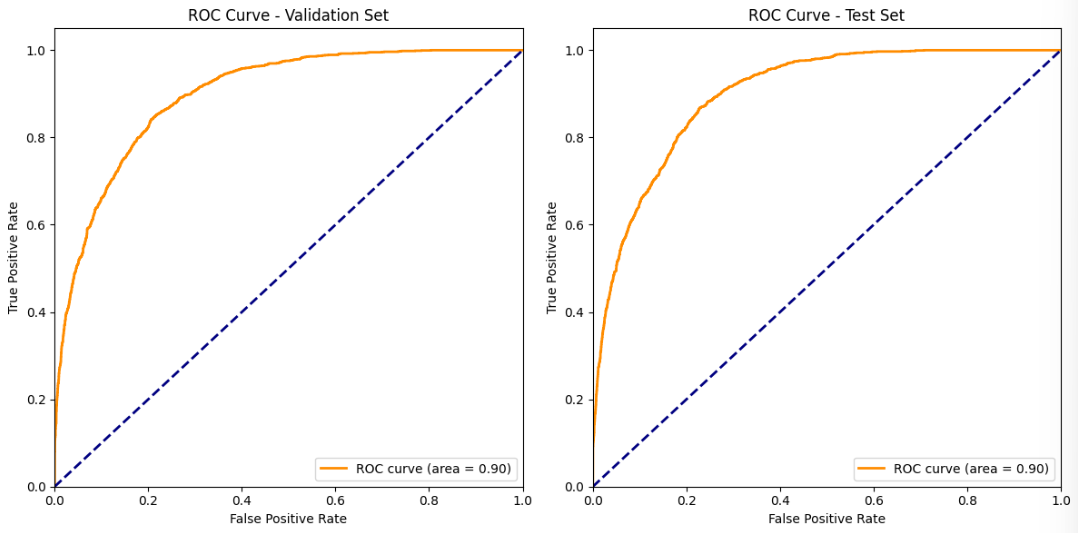



---





```
AFTER TUNING RESULTS
```



 hyperparameter of Logistic Regression using RandomizedSearchCV:

 Best Parameters:
- Solver: `saga`
- Penalty: `l2`
- Max iterations: `1000`
- Regularization strength (C): `0.2336`

 Validation Set Performance:
- **Accuracy**: 0.8103
- **Precision**: 0.5842
- **Recall**: 0.8145
- **F1-Score**: 0.6804
- **AUC-ROC**: 0.8950

 Test Set Performance:
- **Accuracy**: 0.8075
- **Precision**: 0.5791
- **Recall**: 0.8168
- **F1-Score**: 0.6777
- **AUC-ROC**: 0.8997

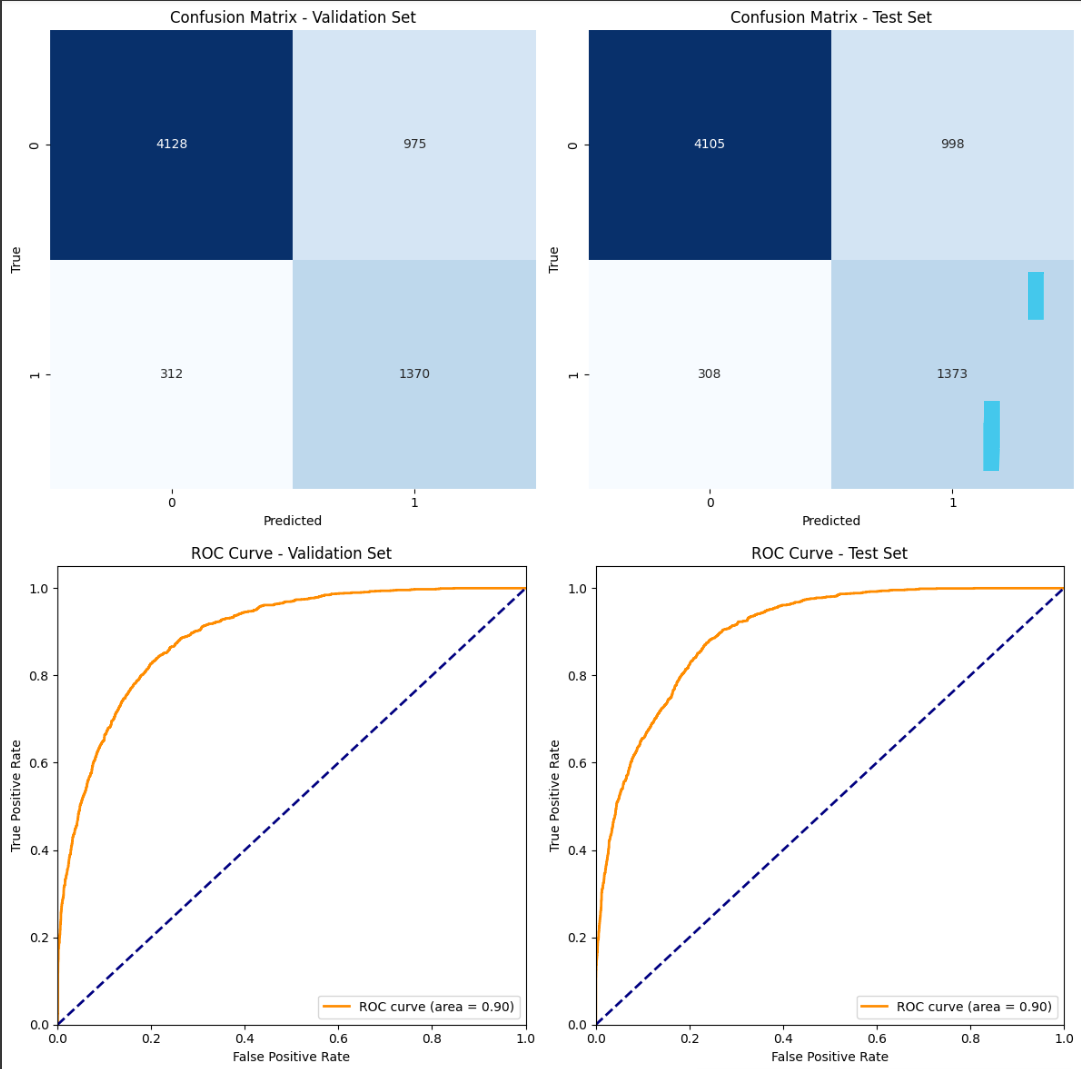



---



RF HYPERPARAMETER TUNING:
- the training here took me a liitle high time complexity -> so i do undersample without scaling -> find the best param -> then finaly apply SMOTE and the best parameters to the RF


- I DO two rounds of RandomizedSearchCV to fine-tune the Random Forest model. In the first round, I tested a broader range of hyperparameters, including more estimators (100, 200), different maximum depths (10, 40, 60), and some few values for minimum samples to split.  After this round, the best param included 200 estimators and a tree depth of 10, among other settings.

- For the second round of tuning, I squeezed the search by reducing the number of estimators (50, 100) and add to the bootstrap option (True/False). The purpose here was to explore more. the results shows  that using 100 estimators with a maximum depth of 10 and no bootstrapping gave the best results.

This two-step tuning process was done to first explore a wider range of possibilities and then trying to focus on a more precise parameters . i do more test cases but i chose to keep the best 2.


Here are the results of hyperparameter tuning and evaluation of Logistic Regression using RandomizedSearchCV:

 Best Parameters:
- Solver: `saga`
- Penalty: `l2`
- Max iterations: `1000`
- Regularization strength (C): `0.2336`

 Validation Set Performance:
- **Accuracy**: 0.8103
- **Precision**: 0.5842
- **Recall**: 0.8145
- **F1-Score**: 0.6804
- **AUC-ROC**: 0.8950

 Test Set Performance:
- **Accuracy**: 0.8075
- **Precision**: 0.5791
- **Recall**: 0.8168
- **F1-Score**: 0.6777
- **AUC-ROC**: 0.8997


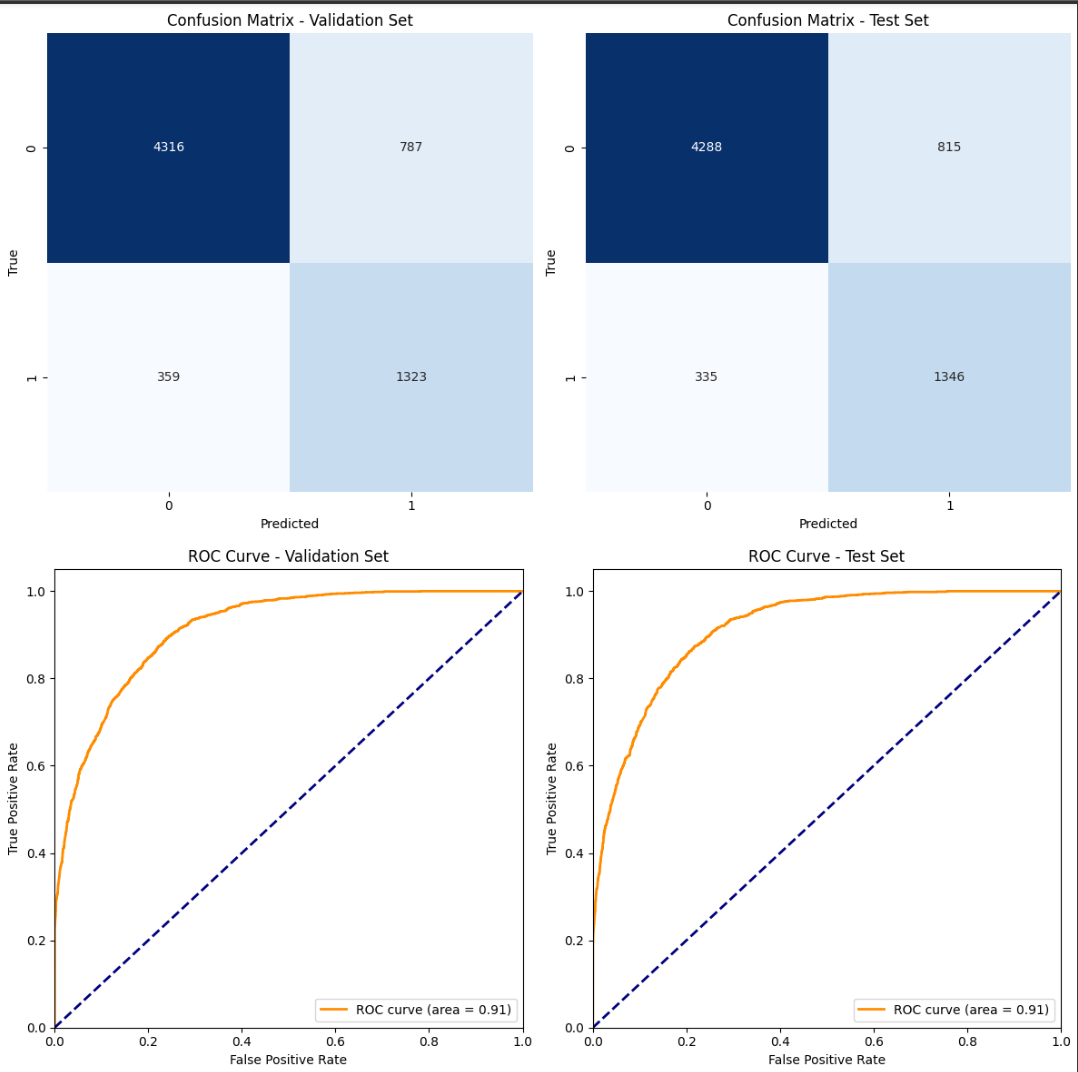

ANN AFTER TUNING:

- **Model Building**: The ANN model was hypertuned using Keras-Tuner with hyperparameters like the number of layers, units per layer, activation functions, learning rate, and dropout rate.
  
- **Best Hyperparameters Found**:
  - Input layer: 64 units
  - Hidden layers: 2 hidden layers with 128 units each
  - Activation function: *tanh*
  - Learning rate: 0.01
  - Dropout rate: 0.1 for each layer
  
- **Training Process**:
  - Trained the model on the SMOTE-oversampled training data with early stopping to prevent overfitting.
  - Used a batch size of 128 and trained for 50 epochs.

- **Model Evaluation**:
  - Validation Set Accuracy: 0.8131
  - Test Set Accuracy: 0.8112

- **Confusion Matrix**: The confusion matrices for both validation and test sets showed reasonable classification results, with a good balance between true positives and true negatives.

- **ROC Curves**:
  - Validation ROC AUC: 0.91
  - Test ROC AUC: 0.90

- **Learning Curves**: Both accuracy and loss plots showed steady improvement during training, with the validation accuracy closely tracking the training accuracy, suggesting no major overfitting.



```
The learning curve is realy bad after i tuned the model  
```





```
i comment the code of tuning bec it took more than hour running and i save the best param and train them on a new ANN model
```



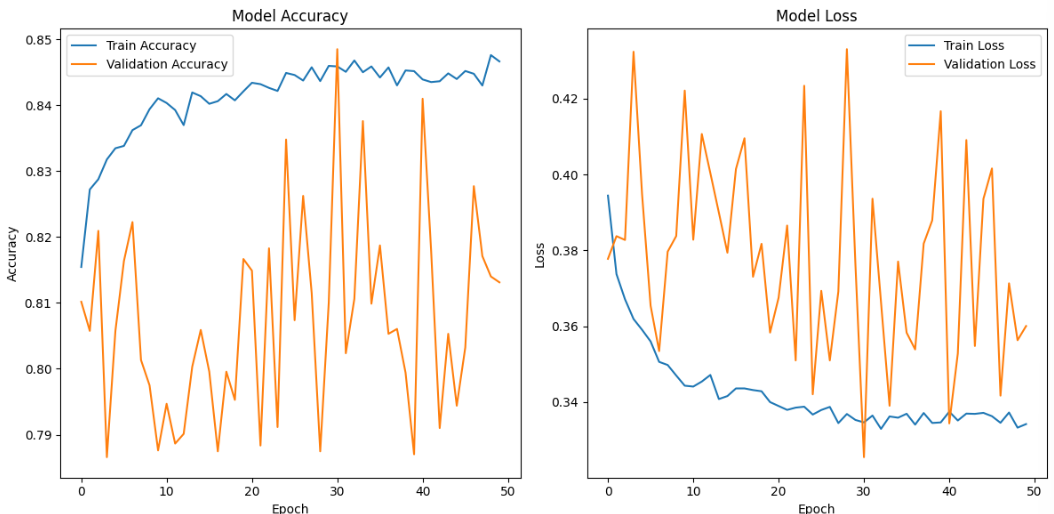

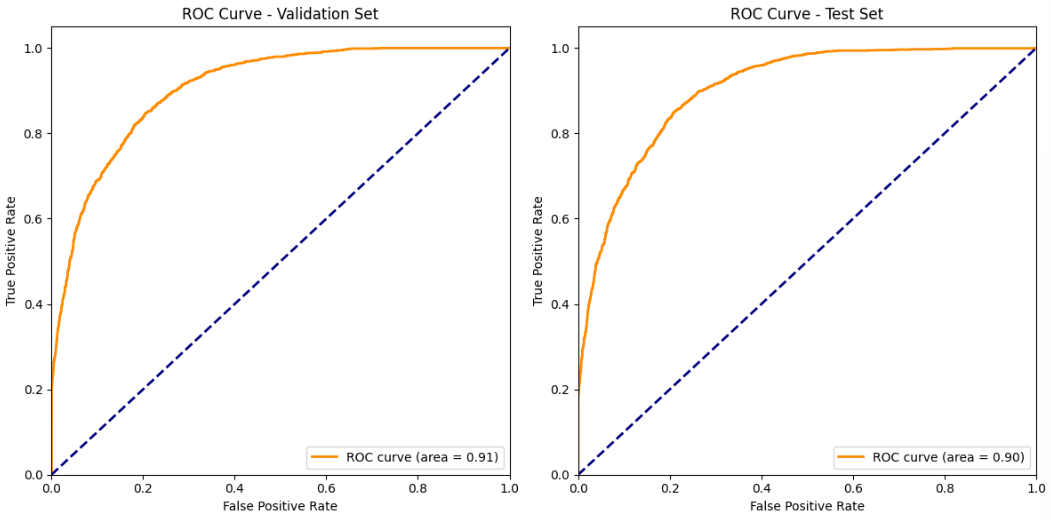

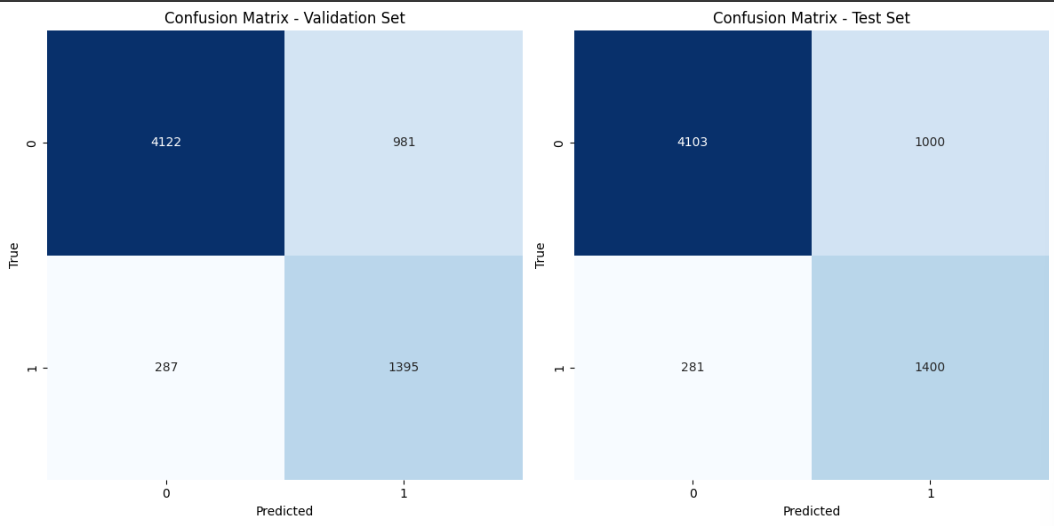

#Summary of Results

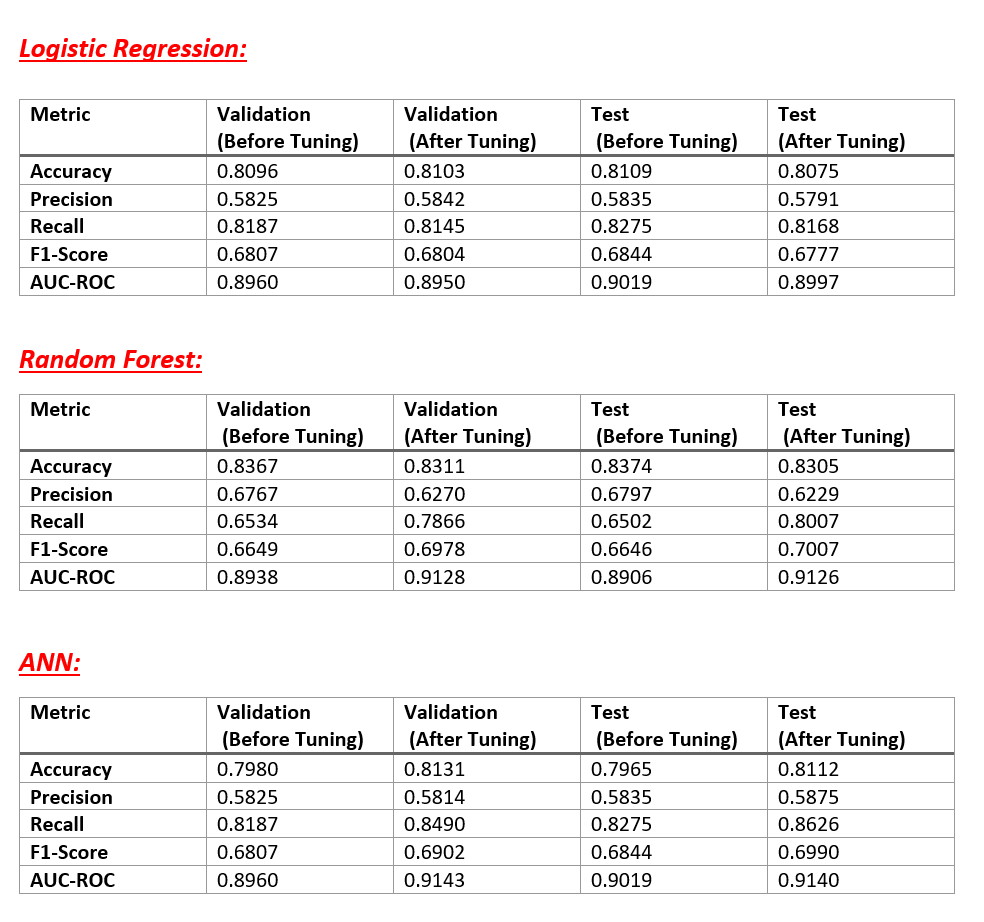


#Libraries to Install



In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


#Libraries

In [ ]:
import numpy as np                      #to deal with arrays and its operations
import plotly.express as px             #visualization library
import matplotlib.pyplot as plt         #visualization library
import seaborn as sns                   #visualization library
import pandas as pd                     #lib that have the datastructures series and dataframe and their operations


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

# ml models Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier  # For classification
from sklearn.linear_model import LogisticRegression  # For classification

# ann libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
# evaluation metrices libraries (accuracy, precision, recall, F1-score)
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#GridSearchCV and RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.experimental import enable_halving_search_cv  # To enable the halving search
from sklearn.model_selection import HalvingRandomSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


#EDA

In [ ]:
df=pd.read_csv('/content/adult - adult.csv')

In [ ]:
df.shape

(48842, 15)

In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
# Adjust pandas settings to display all columns
pd.set_option('display.max_columns', None)  # None means no limit
pd.set_option('display.expand_frame_repr', False)  # Prevent line breaks

# Now display the first 5 rows of your DataFrame
df.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
df.nunique()

,0
age,74
workclass,9
fnlwgt,28523
education,16
educational-num,16
marital-status,7
occupation,15
relationship,6
race,5
gender,2




```
I will Drop fnlwgt because its correlation with the target equal to -0.0063 which was the lowest correlation after i target encode all columns

the meaning of this feature is not clear and will not be good for training
```



In [ ]:
df.drop('fnlwgt',axis=1,inplace=True)

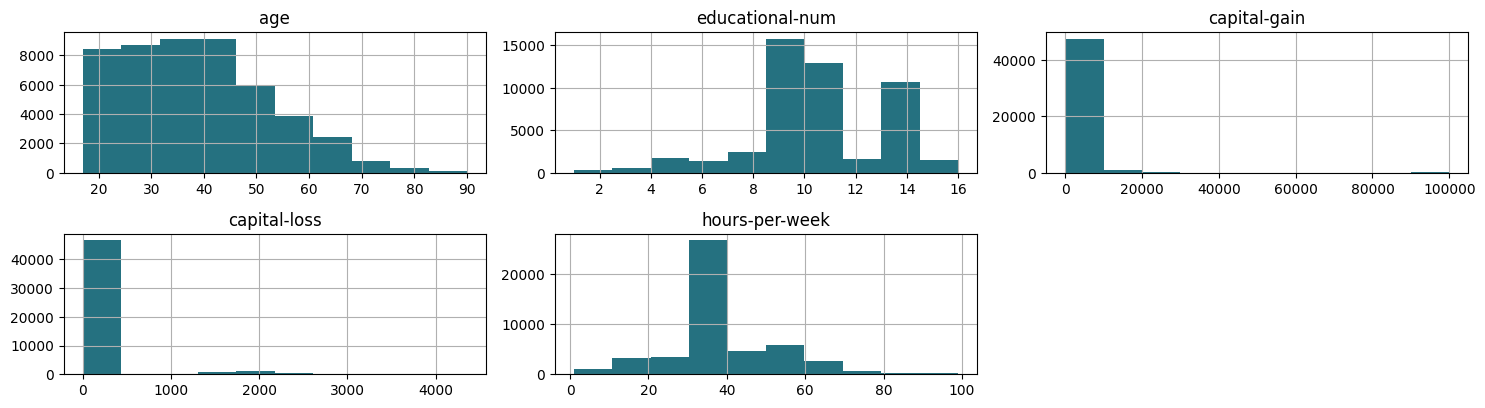

In [ ]:
df.hist(figsize=(15, 10),color='#257180', layout=(df.shape[1] // 3 + (df.shape[1] % 3 > 0), 3))
plt.tight_layout()
plt.show()

In [ ]:

# Display unique values for each column
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique values in column '{column}': {unique_values}")
    print()
    print()

Unique values in column 'age': [25 38 28 44 18 34 29 63 24 55 65 36 26 58 48 43 20 37 40 72 45 22 23 54
 32 46 56 17 39 52 21 42 33 30 47 41 19 69 50 31 59 49 51 27 57 61 64 79
 73 53 77 80 62 35 68 66 75 60 67 71 70 90 81 74 78 82 83 85 76 84 89 88
 87 86]


Unique values in column 'workclass': ['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


Unique values in column 'education': ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']


Unique values in column 'educational-num': [ 7  9 12 10  6 15  4 13 14 16  3 11  5  8  2  1]


Unique values in column 'marital-status': ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']


Unique values in column 'occupation': ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' '

In [ ]:
df['native-country'].value_counts()

,count
native-country,
United-States,43832
Mexico,951
?,857
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151


#Data Preprocessing

## Dropping missing values

In [ ]:
occNaN = (df['occupation'] == '?').sum()

print(f" occupation Count of '?': {occNaN}")

 occupation Count of '?': 2809


In [ ]:
native_countryNAN = (df['native-country'] == '?').sum()

print(f"'native-country' Count of '?': {native_countryNAN}")

'native-country' Count of '?': 857


In [ ]:
workclassNaN = (df['workclass'] == '?').sum()

print(f"'workclass' Count of '?': {workclassNaN}")

'workclass' Count of '?': 2799


In [ ]:
# Counting the number of records where occupation, workclass, and native-country are "?"
count_filtered_records = len(df[(df['occupation'] == '?') | (df['workclass'] == '?') | (df['native-country'] == '?')])

print(f"Number of records: {count_filtered_records}")


Number of records: 3620


In [ ]:
df.shape

(48842, 14)

In [ ]:
df.drop(df[(df['occupation'] == '?') | (df['workclass'] == '?') | (df['native-country'] == '?')].index, inplace=True)

In [ ]:
48842-3620

45222

In [ ]:
df.shape

(45222, 14)

In [ ]:
df.columns

Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')



```
Summary :   

1. drop the column fnlwgt
2. deop missing values rows

```



## Visualizaion

In [ ]:
df.groupby("race")["income"].value_counts()

race                income
Amer-Indian-Eskimo  <=50K       382
                    >50K         53
Asian-Pac-Islander  <=50K       934
                    >50K        369
Black               <=50K      3694
                    >50K        534
Other               <=50K       308
                    >50K         45
White               <=50K     28696
                    >50K      10207
Name: count, dtype: int64

<Figure size 400x400 with 0 Axes>

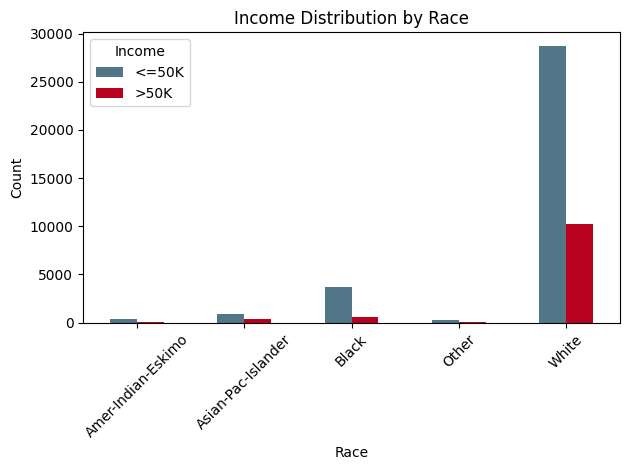

In [ ]:
grouped_data = df.groupby("race")["income"].value_counts().unstack().fillna(0)

# Resetting the index to make 'race' a column
grouped_data = grouped_data.reset_index()

# Creating the visualization
plt.figure(figsize=(4, 4))
grouped_data.plot(kind='bar', x='race', stacked=False, color=['#507687', '#B8001F'], legend=True)

# Adding labels and title
plt.title('Income Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income', labels=['<=50K', '>50K'])
plt.tight_layout()
plt.show()

- the comparison is not fair because count of white people in the dataset is higher than other races .

In [ ]:

# Grouping the data to get counts for each race and income
grouped_data = df.groupby(['race', 'income']).size().reset_index(name='count')

# Calculating the total counts for each race
total_counts = grouped_data.groupby('race')['count'].sum().reset_index(name='total_count')

# Merging to calculate percentages
merged_data = pd.merge(grouped_data, total_counts, on='race')
merged_data['percentage'] = (merged_data['count'] / merged_data['total_count']) * 100

# Display the final DataFrame with percentages
print(merged_data[['race', 'income', 'count', 'total_count', 'percentage']])

                 race income  count  total_count  percentage
0  Amer-Indian-Eskimo  <=50K    382          435   87.816092
1  Amer-Indian-Eskimo   >50K     53          435   12.183908
2  Asian-Pac-Islander  <=50K    934         1303   71.680737
3  Asian-Pac-Islander   >50K    369         1303   28.319263
4               Black  <=50K   3694         4228   87.369915
5               Black   >50K    534         4228   12.630085
6               Other  <=50K    308          353   87.252125
7               Other   >50K     45          353   12.747875
8               White  <=50K  28696        38903   73.762949
9               White   >50K  10207        38903   26.237051




```
- White race has the highest income, with 26% earning >$50K.
- Black and Amer-Indian-Eskimo races earn less, with over 87% in the <=$50K category.
```



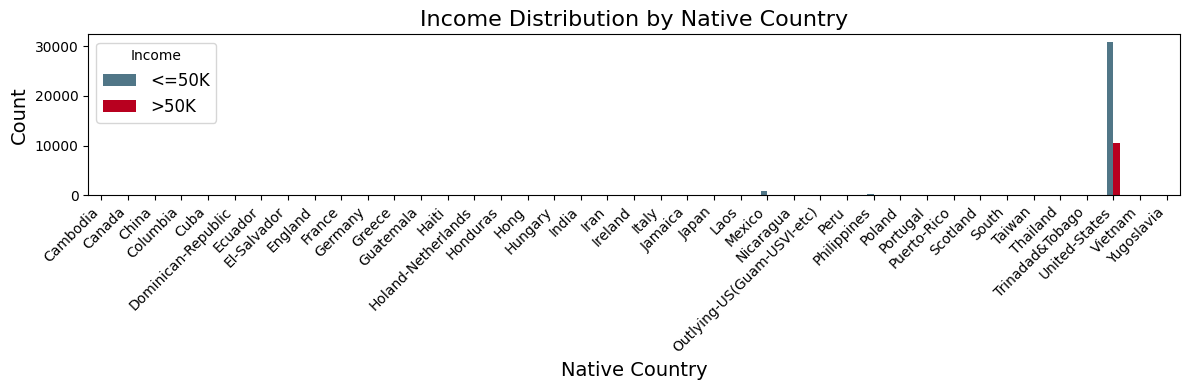

In [ ]:

# Grouping the data by 'native-country' and counting income values
group_data = df.groupby('native-country')["income"].value_counts().unstack().fillna(0)
group_data = group_data.reset_index()

# Creating the visualization with size defined directly in the plot method
group_data.plot(kind='bar', x='native-country', figsize=(12, 4), stacked=False, color=['#507687', '#B8001F'], legend=True)

# Adding labels and title
plt.title('Income Distribution by Native Country', fontsize=16)
plt.xlabel('Native Country', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Rotate x-ticks for better readability
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income', labels=['<=50K', '>50K'], fontsize=12)
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()

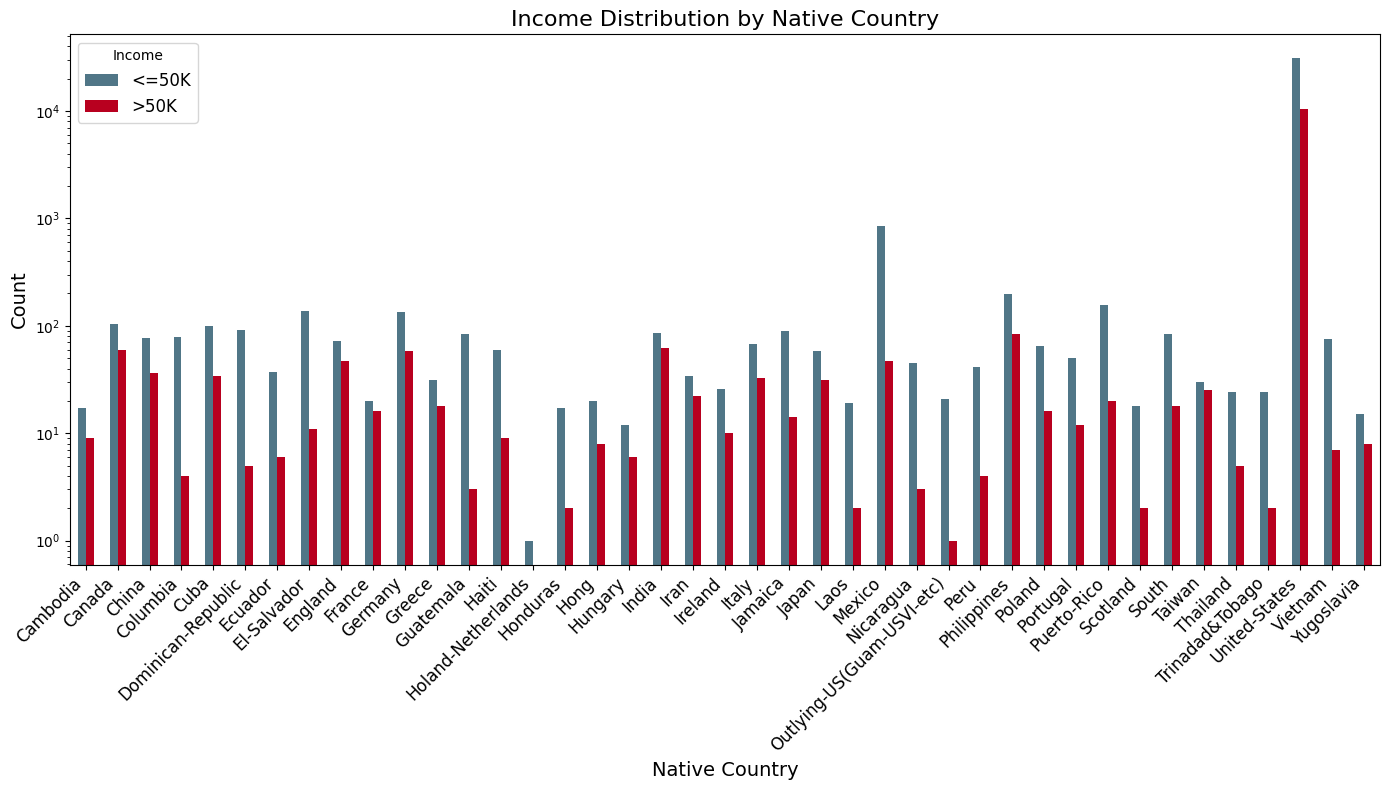

In [ ]:
# Creating the visualization with specified figure size directly in plot
group_data.plot(kind='bar', x='native-country', stacked=False, figsize=(14, 8), color=['#507687', '#B8001F'], legend=True)

# Adding labels and title
plt.title('Income Distribution by Native Country', fontsize=16)
plt.xlabel('Native Country', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Set y-axis to logarithmic scale for better visibility
plt.yscale('log')

# Rotate x-ticks for better readability
plt.xticks(rotation=45, ha='right', fontsize=12)  # Adjusting font size and alignment
plt.legend(title='Income', labels=['<=50K', '>50K'], fontsize=12)
plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
plt.show()



**Visibility: The count for the United States was so high that other bars were barely visible. => i think the analysis on the data if all was from US and white people will lead to better results bec the count of them is so high and i think the classificatioins will be bias to them .**


---

**`Explanation for Using Logarithmic Scale`**
- Log Scale Benefit: I used a logarithmic scale to compress the range, which helped me see and compare the smaller counts for other countries more clearly.








In [ ]:
# Counting the number of individuals from different races whose native country is the United States
race_count_us = df[df['native-country'] == 'United-States']['race'].value_counts()

# Displaying the counts
print(race_count_us)

race
White                 36347
Black                  3962
Amer-Indian-Eskimo      417
Asian-Pac-Islander      398
Other                   168
Name: count, dtype: int64


In [ ]:
df.groupby("gender")["income"].value_counts()

gender  income
Female  <=50K     13026
        >50K       1669
Male    <=50K     20988
        >50K       9539
Name: count, dtype: int64

- Females: 16,192 total (14,423 earn <=50K, 1,769 earn >50K).
- Males: 32,650 total (22,732 earn <=50K, 9,918 earn >50K).
- About 89% of females earn <=50K.
- About 69% of males earn <=50K.
- There are nearly double the number of male workers compared to female workers.
- More males earn over $50K compared to females.
- Further analysis could explore reasons for income differences between genders and examine job types and education effects on income.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              45222 non-null  int64 
 1   workclass        45222 non-null  object
 2   education        45222 non-null  object
 3   educational-num  45222 non-null  int64 
 4   marital-status   45222 non-null  object
 5   occupation       45222 non-null  object
 6   relationship     45222 non-null  object
 7   race             45222 non-null  object
 8   gender           45222 non-null  object
 9   capital-gain     45222 non-null  int64 
 10  capital-loss     45222 non-null  int64 
 11  hours-per-week   45222 non-null  int64 
 12  native-country   45222 non-null  object
 13  income           45222 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


#Encoding

columns description from kaggle

Age – continuous feature

Workclass – continuous feature

fnlwgt – final weight of object, continuous feature

Education – categorical feature

Education_Num – number of years of education, continuous feature

Martial_Status – categorical feature

Occupation – categorical feature

Relationship – categorical feature

Race – categorical feature

Sex – categorical feature

Capital_Gain – continuous feature

Capital_Loss – continuous feature

Hours_per_week – continuous feature

Country – categorical feature

Target – earnings level, categorical (binary) feature.

In [ ]:
df_encoded = df.copy()

##Binary Encoding

In [ ]:
df_encoded ['gender'] = df_encoded ['gender'].map({'Male': 1, 'Female': 0})

In [ ]:
df_encoded.head(1)

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,<=50K


##Target Encoding

In [ ]:

# List of categorical columns to target encode
categorical_cols = ['workclass', 'education', 'marital-status',
                    'occupation', 'relationship', 'race', 'native-country']

# Convert the target to numeric: assuming 'income' has values '>50K' and '<=50K'
df_encoded['income'] = df_encoded['income'].map({'>50K': 1, '<=50K': 0})

# Initialize the target encoder
target_encoder = ce.TargetEncoder(cols=categorical_cols)

# Fit and transform the encoder on the DataFrame
df_encoded[categorical_cols] = target_encoder.fit_transform(df_encoded[categorical_cols], df_encoded['income'])

In [ ]:
df_encoded.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,0.217702,0.054972,7,0.048020,0.122896,0.015847,0.126301,1,0,0,40,0.253027,0
1,38,0.217702,0.163431,9,0.454239,0.116216,0.455748,0.262371,1,0,0,50,0.253027,0
2,28,0.295161,0.264101,12,0.454239,0.314549,0.455748,0.262371,1,0,0,40,0.253027,1
3,44,0.217702,0.201030,10,0.454239,0.122896,0.455748,0.126301,1,7688,0,40,0.253027,1
5,34,0.217702,0.067048,6,0.048020,0.040765,0.104939,0.262371,1,0,0,30,0.253027,0


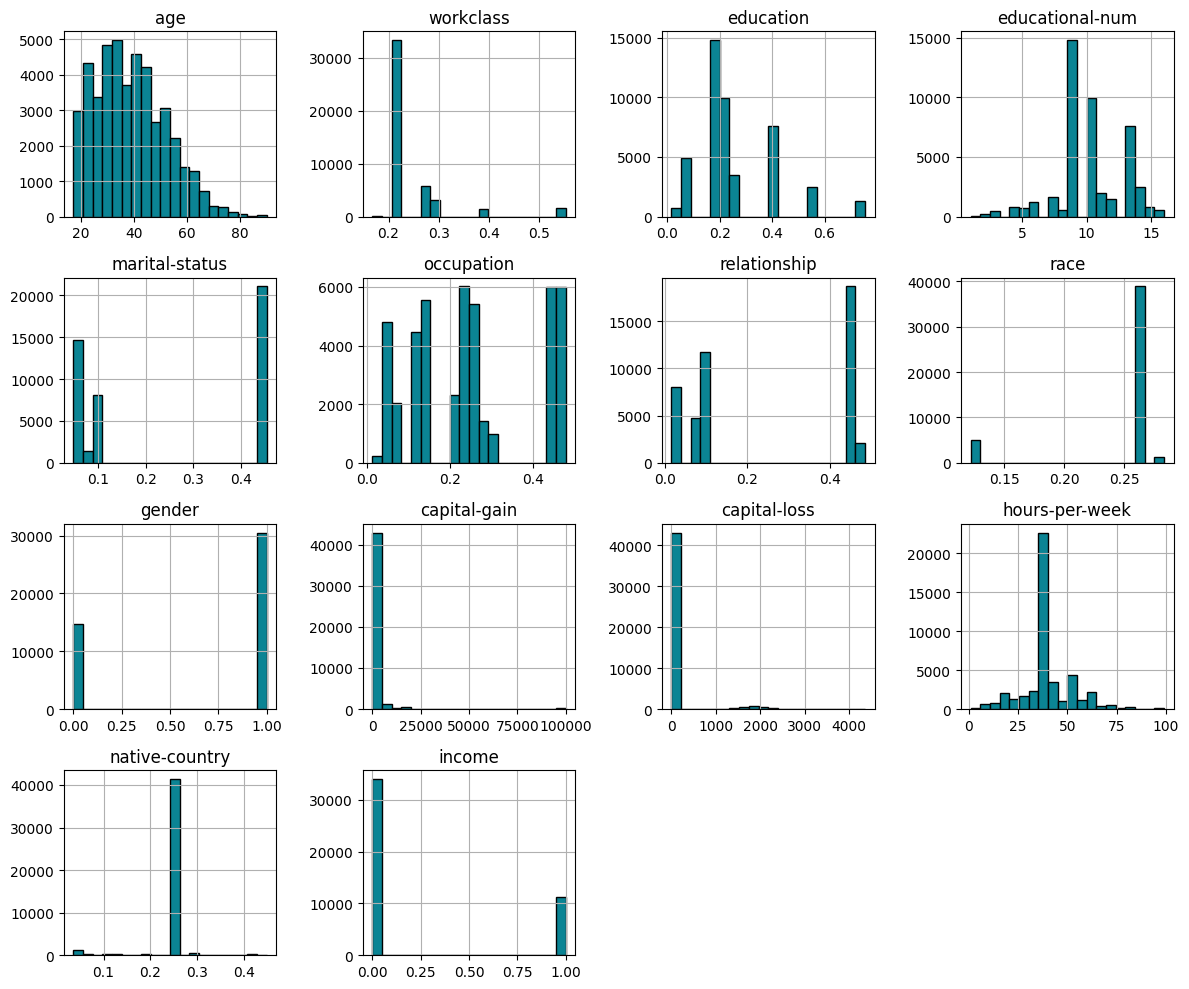

In [ ]:

# Plot histograms for all columns in df_encoded
df_encoded.hist(figsize=(12, 10), bins=20, color='#0B8494',edgecolor='black')

# Display the plots
plt.tight_layout()
plt.show()

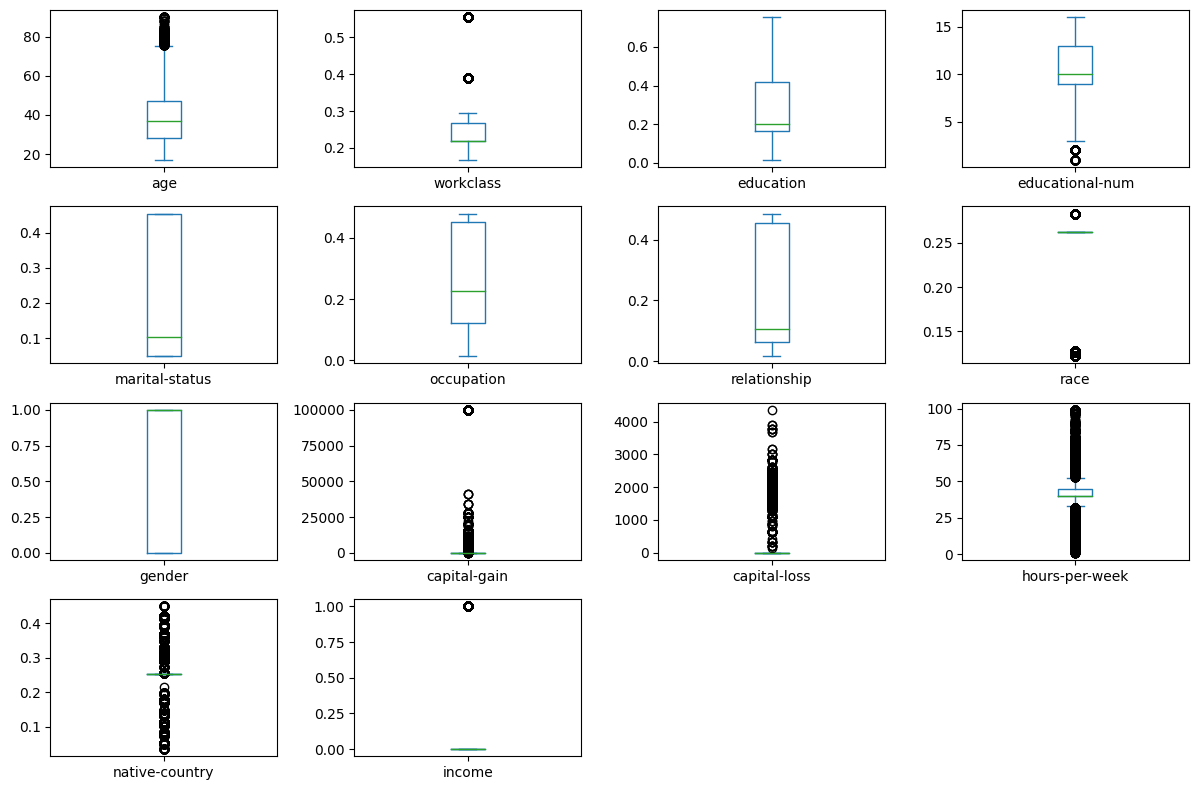

In [ ]:
# Plot boxplots for all columns to check for outliers
df_encoded.plot(kind='box', figsize=(12, 8), subplots=True, layout=(4, 4), sharex=False, sharey=False)

# Display the plots
plt.tight_layout()
plt.show()

- capital-gain and capital-loss: Significant number of outliers on the higher end.
- hours-per-week: Some outliers, especially in the upper range (more than 75 hours).
- age: A few outliers for older ages (over 80).
- educational-num: A few outliers on the higher end (values close to 16).
- race and native-country: A few minor outliers in these categorical features.


In [ ]:
df_encoded['income'].value_counts()

,count
income,
0,34014
1,11208


#Correlations

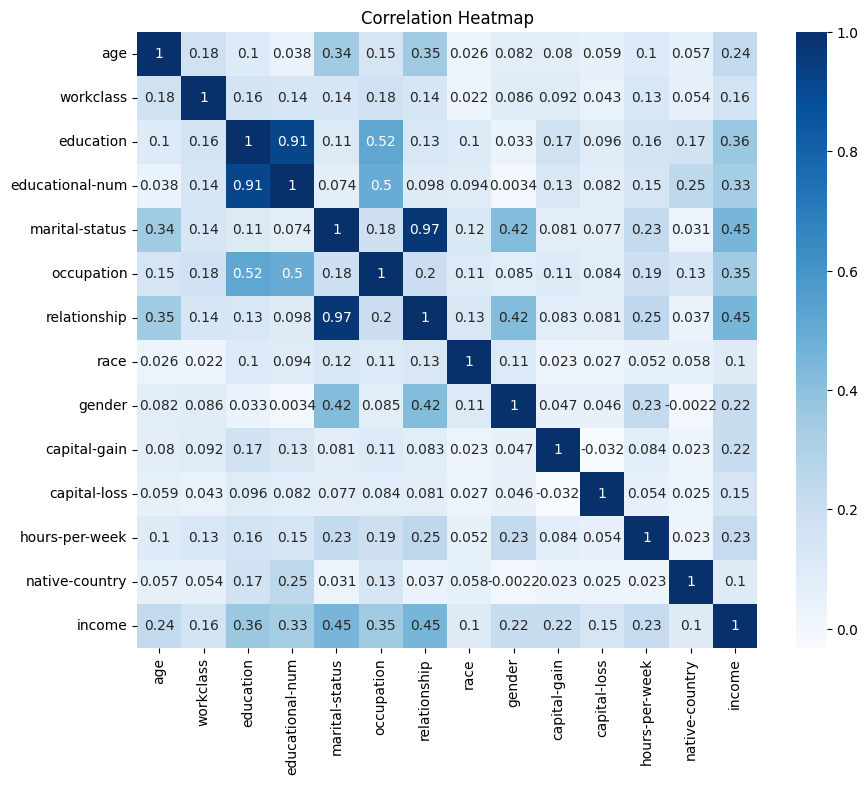

In [ ]:
#heat Map
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()



'relationship' - 'martial' status have high correlation with each other -> we may drop one

education - education_num -> have high correlation with each other , education is more representive and have more logical values than education column -> we may drop one

##Correlations of target encoded columns with the target

In [ ]:
correlation_matrix = df_encoded.corr()

# Extract correlations with the target variable 'income'
target_correlations = correlation_matrix['income'].sort_values(ascending=False)

# Display the correlations
print(target_correlations)

income             1.000000
relationship       0.454877
marital-status     0.448805
education          0.364130
occupation         0.346041
educational-num    0.332800
age                0.237040
hours-per-week     0.227199
capital-gain       0.221034
gender             0.215760
workclass          0.163350
capital-loss       0.148687
race               0.100009
native-country     0.099936
Name: income, dtype: float64


#Feature Engineering

In [ ]:
# Log transformation of 'capital-gain' and 'capital-loss'
df_encoded['log_capital_gain'] = np.log1p(df_encoded['capital-gain'])
df_encoded['log_capital_loss'] = np.log1p(df_encoded['capital-loss'])

# Check correlation with target
print("Correlation of log_capital_gain:", df_encoded['log_capital_gain'].corr(df_encoded['income']))
print("Correlation of log_capital_loss:", df_encoded['log_capital_loss'].corr(df_encoded['income']))

print("original:")
print("capital-gain       0.221034")
print('capital-loss       0.148687')

Correlation of log_capital_gain: 0.2877395790005135
Correlation of log_capital_loss: 0.13925338078101523
original:
capital-gain       0.221034
capital-loss       0.148687


In [ ]:
# Interaction between 'age' and 'hours-per-week'
df_encoded['age_hours_interaction'] = df_encoded['age'] * df_encoded['hours-per-week']
df_encoded['capital_net'] = df_encoded['capital-gain'] - df_encoded['capital-loss']

# Check correlation with target
print("Correlation of age_hours_interaction:", df_encoded['age_hours_interaction'].corr(df_encoded['income']))
print("Correlation of capital_net:", df_encoded['capital_net'].corr(df_encoded['income']))
print("original:")
print("age                0.237040")
print("hours-per-week     0.227199")
print("capital-gain       0.221034")
print('capital-loss       0.148687')

Correlation of age_hours_interaction: 0.31780618756987616
Correlation of capital_net: 0.21233680540704306
original:
age                0.237040
hours-per-week     0.227199
capital-gain       0.221034
capital-loss       0.148687


In [ ]:
df_encoded.columns

Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income',
       'log_capital_gain', 'log_capital_loss', 'age_hours_interaction',
       'capital_net'],
      dtype='object')

Capital Gain: Important; suggests wealth/investments, often linked to higher income.

Capital Loss: Less direct; indicates investment activity, may still correlate with higher income.

In [ ]:
# df_encoded['age_squared'] = df_encoded['age'] ** 2
# df_encoded['capital_gain_squared'] = df_encoded['capital-gain'] ** 2
# df_encoded['hours_per_week_squared'] = df_encoded['hours-per-week'] ** 2
# df_encoded['capital_net_squared'] = df_encoded['capital_net'] ** 2


#THEIR IMPACT WAS NEGATIVE TO MODEL ACC (I TRY THEM)

In [ ]:
df_encoded['education_occupation'] = df_encoded['education'] * df_encoded['occupation']
df_encoded['gender_relationship'] = df_encoded['gender'] * df_encoded['relationship']
df_encoded['age_relationship'] = df_encoded['age'] * df_encoded['relationship']

correlation_matrix = df_encoded.corr()
new_feature_correlations = correlation_matrix['income'][['education_occupation', 'gender_relationship', 'age_relationship']]

print("Correlations of new features with income:")
print(new_feature_correlations)


Correlations of new features with income:
education_occupation    0.397749
gender_relationship     0.401443
age_relationship        0.450251
Name: income, dtype: float64


In [ ]:
df_encoded['relationship_hours_per_week'] = df_encoded['relationship'] * df_encoded['hours-per-week']
correlation_matrix = df_encoded.corr()
new_feature_correlation = correlation_matrix['income']['relationship_hours_per_week']

# Print the correlation
print(f"Correlation of 'relationship_hours_per_week' with income: {new_feature_correlation}")

Correlation of 'relationship_hours_per_week' with income: 0.46443488169210073


In [ ]:
df_encoded['age_occupation'] = df_encoded['age'] * df_encoded['occupation']
df_encoded['education_hours_per_week'] = df_encoded['education'] * df_encoded['hours-per-week']
df_encoded['relationship_marital_status'] = df_encoded['relationship'] * df_encoded['marital-status']


In [ ]:
df_encoded['education_squared'] = df_encoded['education'] ** 2
df_encoded['relationship_squared'] = df_encoded['relationship'] ** 2
df_encoded['age_squared'] = df_encoded['age'] ** 2


In [ ]:
correlation_matrix = df_encoded.corr()
target_correlations = correlation_matrix['income'].sort_values(ascending=False)
print(target_correlations)


income                         1.000000
relationship_hours_per_week    0.464435
relationship                   0.454877
relationship_squared           0.452033
relationship_marital_status    0.451963
age_relationship               0.450251
marital-status                 0.448805
gender_relationship            0.401443
age_occupation                 0.400379
education_occupation           0.397749
education_hours_per_week       0.395336
education                      0.364130
education_squared              0.350017
occupation                     0.346041
educational-num                0.332800
age_hours_interaction          0.317806
log_capital_gain               0.287740
age                            0.237040
hours-per-week                 0.227199
capital-gain                   0.221034
gender                         0.215760
capital_net                    0.212337
age_squared                    0.193888
workclass                      0.163350
capital-loss                   0.148687


In [ ]:
df_encoded.isnull().sum()

,0
age,0
workclass,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0
capital-gain,0


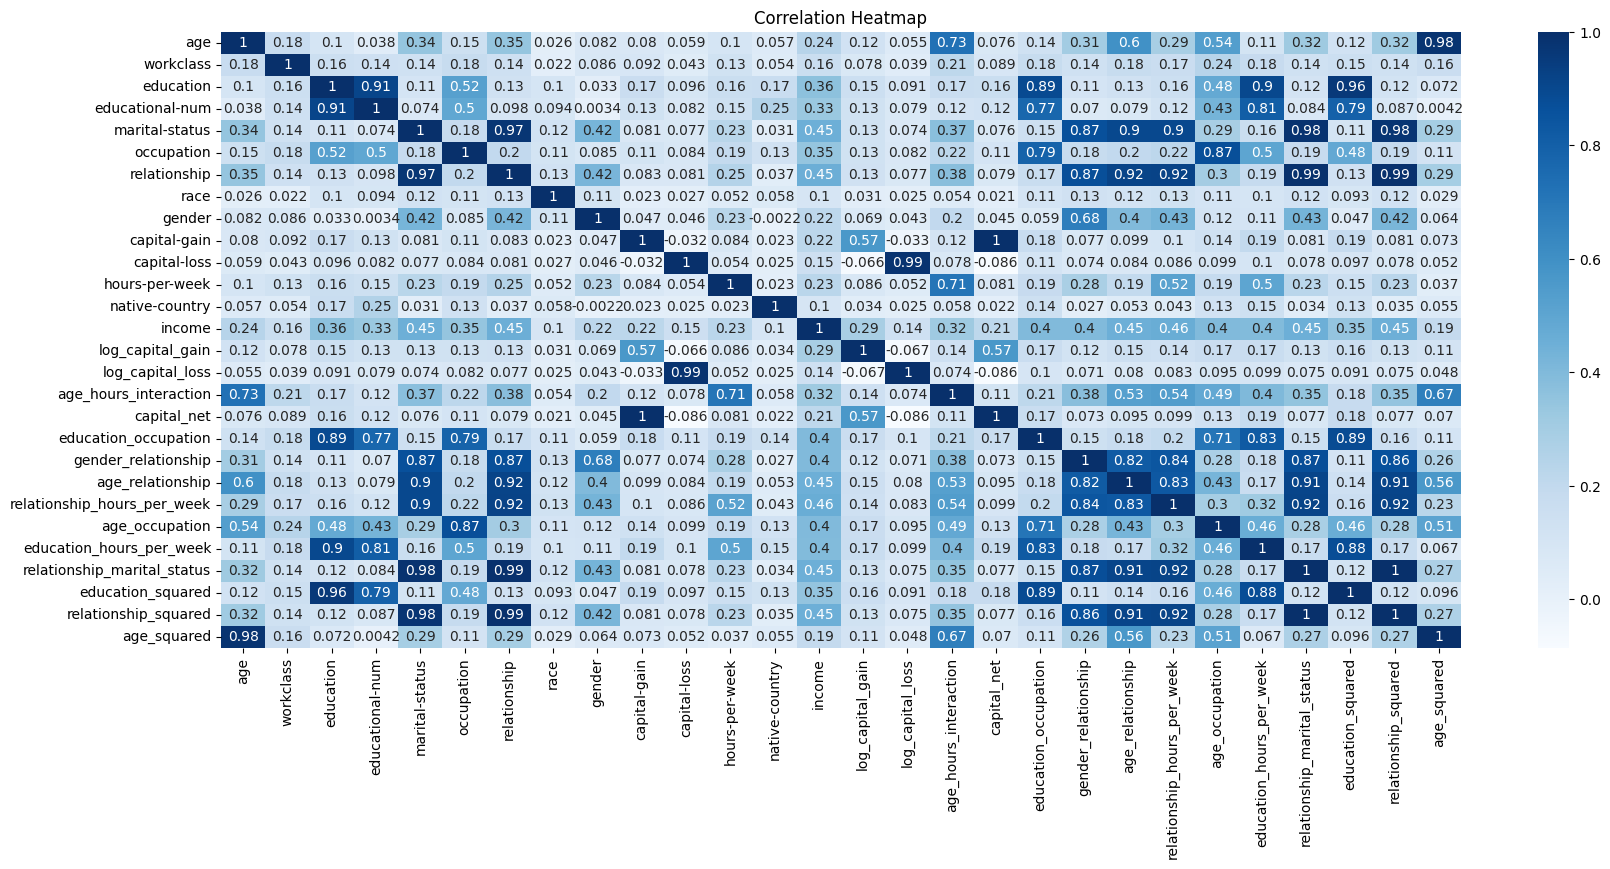

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
# Dropping redundant features
df_encoded.drop(columns=[
    'education_squared',
    'relationship_squared',
    'age_squared',
    'age_relationship',
    'education_hours_per_week',
    'relationship_marital_status',
    'educational-num',
    'relationship'

], errors='ignore',inplace=True)

# Verify the remaining columns
print(df_encoded.columns)


Index(['age', 'workclass', 'education', 'marital-status', 'occupation', 'race',
       'gender', 'capital-gain', 'capital-loss', 'hours-per-week',
       'native-country', 'income', 'log_capital_gain', 'log_capital_loss',
       'age_hours_interaction', 'capital_net', 'education_occupation',
       'gender_relationship', 'relationship_hours_per_week', 'age_occupation'],
      dtype='object')


In [ ]:
# Dropping additional features with low correlation with income
df_encoded.drop(columns=[
    'log_capital_loss',
    'race',
    'native-country'
], errors='ignore',inplace=True)

# Verify remaining columns
print(df_encoded.columns)

Index(['age', 'workclass', 'education', 'marital-status', 'occupation',
       'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'income',
       'log_capital_gain', 'age_hours_interaction', 'capital_net',
       'education_occupation', 'gender_relationship',
       'relationship_hours_per_week', 'age_occupation'],
      dtype='object')


In [ ]:
correlation_matrix = df_encoded.corr()
target_correlations = correlation_matrix['income'].sort_values(ascending=False)
print(target_correlations)


income                         1.000000
relationship_hours_per_week    0.464435
marital-status                 0.448805
gender_relationship            0.401443
age_occupation                 0.400379
education_occupation           0.397749
education                      0.364130
occupation                     0.346041
age_hours_interaction          0.317806
log_capital_gain               0.287740
age                            0.237040
hours-per-week                 0.227199
capital-gain                   0.221034
gender                         0.215760
capital_net                    0.212337
workclass                      0.163350
capital-loss                   0.148687
Name: income, dtype: float64


In [ ]:
df.columns

Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

#Modeling Preperations

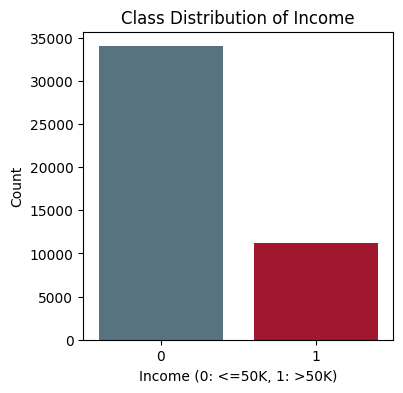

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot(x=df_encoded['income'], hue=df_encoded['income'], palette=['#507687', '#B8001F'], legend=False)
plt.title('Class Distribution of Income')
plt.xlabel('Income (0: <=50K, 1: >50K)')
plt.ylabel('Count')
plt.show()

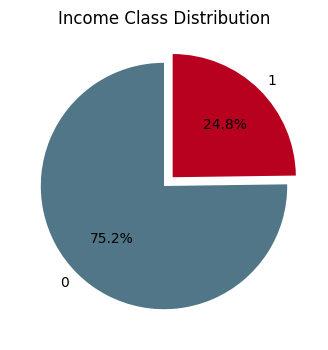

In [ ]:
plt.figure(figsize=(4,4))
df_encoded['income'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#507687', '#B8001F'], explode=[0, 0.1])
plt.title('Income Class Distribution')
plt.ylabel('')  # Remove y-label for a cleaner pie chart
plt.show()

##Splitting

In [ ]:
X = df_encoded.drop(columns=['income'])  # Features
y = df_encoded['income']  # Target

# 1st split: 85% train+validation, 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# 2nd split: Split train+validation (85%) into 70% training and 15% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)


##Handling Imbalance

In [ ]:
# Apply SMOTE on the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
# Print class distributions before and after SMOTE
print("Original class distribution in training data:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

# Print the shapes of the datasets
print("Original Training Set Shape (X_train):", X_train.shape)
print("Original Training Set Shape (y_train):", y_train.shape)

print("Training Set Shape After SMOTE (X_train_smote):", X_train_smote.shape)
print("Training Set Shape After SMOTE (y_train_smote):", y_train_smote.shape)

print("Validation Set Shape (X_val):", X_val.shape)
print("Validation Set Shape (y_val):", y_val.shape)

print("Test Set Shape (X_test):", X_test.shape)
print("Test Set Shape (y_test):", y_test.shape)

Original class distribution in training data:
income
0    23808
1     7845
Name: count, dtype: int64

Class distribution after SMOTE:
income
0    23808
1    23808
Name: count, dtype: int64
Original Training Set Shape (X_train): (31653, 16)
Original Training Set Shape (y_train): (31653,)
Training Set Shape After SMOTE (X_train_smote): (47616, 16)
Training Set Shape After SMOTE (y_train_smote): (47616,)
Validation Set Shape (X_val): (6785, 16)
Validation Set Shape (y_val): (6785,)
Test Set Shape (X_test): (6784, 16)
Test Set Shape (y_test): (6784,)


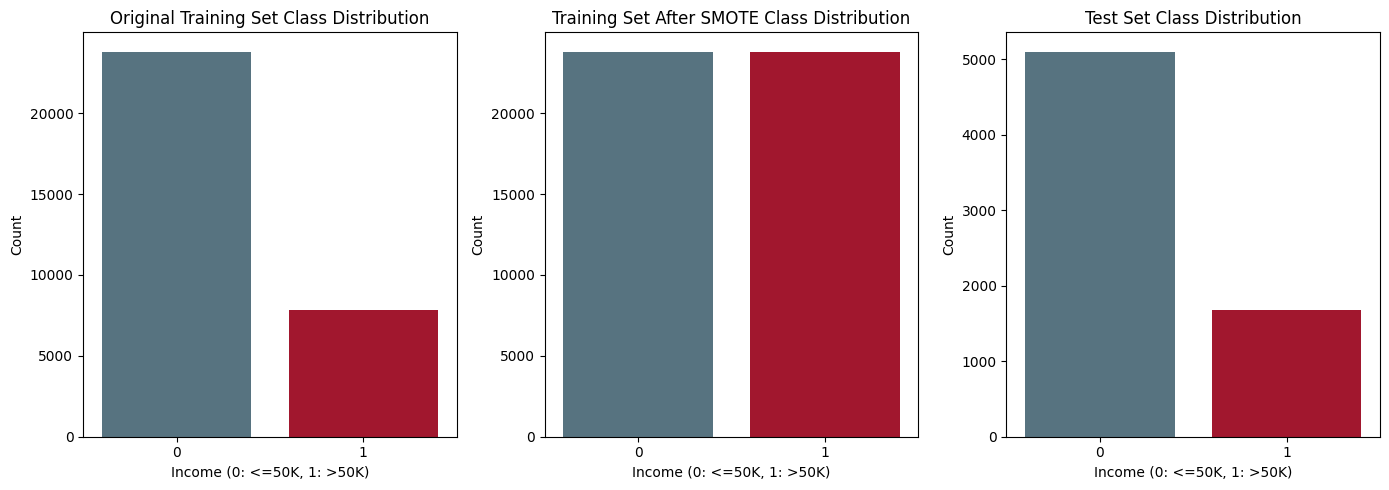

In [ ]:
plt.figure(figsize=(14, 5))

# Original Training Set
plt.subplot(1, 3, 1)
sns.countplot(x=y_train, hue=y_train, palette=['#507687', '#B8001F'], legend=False)
plt.title('Original Training Set Class Distribution')
plt.xlabel('Income (0: <=50K, 1: >50K)')
plt.ylabel('Count')

# Training Set after SMOTE
plt.subplot(1, 3, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette=['#507687', '#B8001F'], legend=False)
plt.title('Training Set After SMOTE Class Distribution')
plt.xlabel('Income (0: <=50K, 1: >50K)')
plt.ylabel('Count')

# Test Set
plt.subplot(1, 3, 3)
sns.countplot(x=y_test, hue=y_test, palette=['#507687', '#B8001F'], legend=False)
plt.title('Test Set Class Distribution')
plt.xlabel('Income (0: <=50K, 1: >50K)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

##Standarization

In [ ]:

# Standarization for logistic regression and ANN --> after SMOTE
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

# Transform the validation and test sets using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Set Shape (X_train_smote_scaled):", X_train_smote_scaled.shape)
print("Scaled Validation Set Shape (X_val_scaled):", X_val_scaled.shape)
print("Scaled Test Set Shape (X_test_scaled):", X_test_scaled.shape)

Scaled Training Set Shape (X_train_smote_scaled): (47616, 16)
Scaled Validation Set Shape (X_val_scaled): (6785, 16)
Scaled Test Set Shape (X_test_scaled): (6784, 16)


#ML models and ANN (before tuning)

## Logistic Regression

In [ ]:

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42)

# Train Logistic Regression model on scaled training data (SMOTE applied)
log_reg.fit(X_train_smote_scaled, y_train_smote)

# Predict on validation set
y_val_pred_log = log_reg.predict(X_val_scaled)
y_val_prob_log = log_reg.predict_proba(X_val_scaled)[:, 1]

# Evaluate the performance
accuracy_log = accuracy_score(y_val, y_val_pred_log)
precision_log = precision_score(y_val, y_val_pred_log)
recall_log = recall_score(y_val, y_val_pred_log)
f1_log = f1_score(y_val, y_val_pred_log)
auc_log = roc_auc_score(y_val, y_val_prob_log)

# Print the evaluation metrics
print(f"Logistic Regression (Validation Set) - Accuracy: {accuracy_log}")
print(f"Precision: {precision_log}, Recall: {recall_log}, F1-Score: {f1_log}, AUC-ROC: {auc_log}")

Logistic Regression (Validation Set) - Accuracy: 0.8097273397199706
Precision: 0.5832978270132083, Recall: 0.8139120095124851, F1-Score: 0.6795730950608091, AUC-ROC: 0.8952760412552548


In [ ]:
# Predict on the test set
y_test_pred_log = log_reg.predict(X_test_scaled)
y_test_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate the performance on the test set
accuracy_test_log = accuracy_score(y_test, y_test_pred_log)
precision_test_log = precision_score(y_test, y_test_pred_log)
recall_test_log = recall_score(y_test, y_test_pred_log)
f1_test_log = f1_score(y_test, y_test_pred_log)
auc_test_log = roc_auc_score(y_test, y_test_prob_log)

# Print the evaluation metrics for the test set
print(f"\nLogistic Regression (Test Set) - Accuracy: {accuracy_test_log}")
print(f"Precision: {precision_test_log}, Recall: {recall_test_log}, F1-Score: {f1_test_log}, AUC-ROC: {auc_test_log}")


Logistic Regression (Test Set) - Accuracy: 0.8077830188679245
Precision: 0.5795694385816801, Recall: 0.816775728732897, F1-Score: 0.6780246913580247, AUC-ROC: 0.9000754592223513


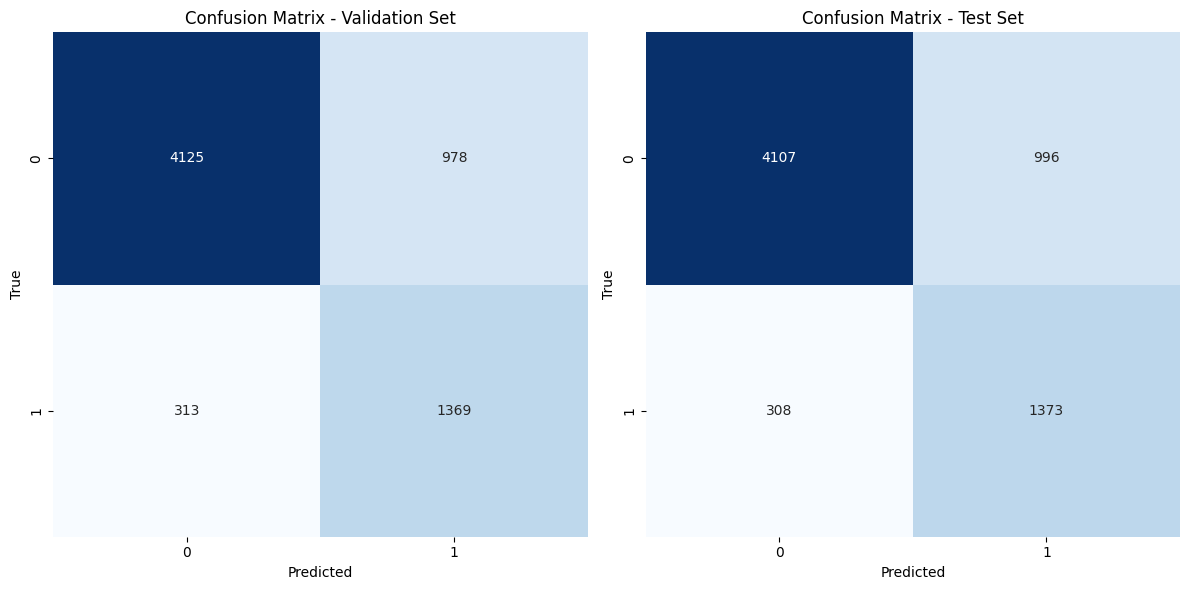

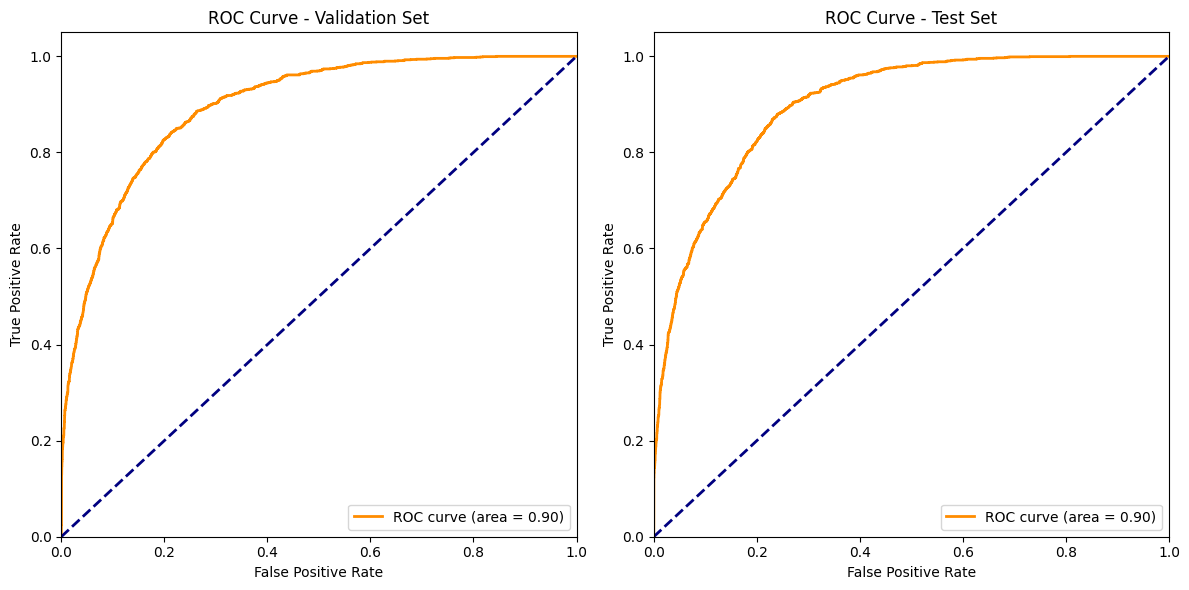

In [ ]:
# Create subplots to put the 2 img on a row
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Confusion Matrix - Validation Set
cm_val = confusion_matrix(y_val, y_val_pred_log)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - Validation Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confusion Matrix - Test Set
cm_test = confusion_matrix(y_test, y_test_pred_log)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

#  ROC Curve for Validation and Test Set
# Create subplots to put the 2 img on a row
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ROC Curve for the validation Set
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob_log)
roc_auc_val = auc(fpr_val, tpr_val)
axes[0].plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Validation Set')
axes[0].legend(loc="lower right")

# ROC Curve for the test Set
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_log)
roc_auc_test = auc(fpr_test, tpr_test)
axes[1].plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Random Forest

In [ ]:

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Train Random Forest model on unscaled training data (SMOTE applied)
rf.fit(X_train_smote, y_train_smote)

# Predict on validation set
y_val_pred_rf = rf.predict(X_val)
y_val_prob_rf = rf.predict_proba(X_val)[:, 1]

# Evaluate the performance
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)
auc_rf = roc_auc_score(y_val, y_val_prob_rf)

# Print the evaluation metrics
print(f"Random Forest (Validation Set) - Accuracy: {accuracy_rf}")
print(f"Precision: {precision_rf}, Recall: {recall_rf}, F1-Score: {f1_rf}, AUC-ROC: {auc_rf}")

Random Forest (Validation Set) - Accuracy: 0.8359616801768607
Precision: 0.6750769230769231, Recall: 0.6521997621878716, F1-Score: 0.6634411853643786, AUC-ROC: 0.8932505255004923


In [ ]:
# Predict on the test set
y_test_pred_rf = rf.predict(X_test)
y_test_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate the performance on the test set
accuracy_test_rf = accuracy_score(y_test, y_test_pred_rf)
precision_test_rf = precision_score(y_test, y_test_pred_rf)
recall_test_rf = recall_score(y_test, y_test_pred_rf)
f1_test_rf = f1_score(y_test, y_test_pred_rf)
auc_test_rf = roc_auc_score(y_test, y_test_prob_rf)

# Print the evaluation metrics for the test set
print(f"\nRandom Forest (Test Set) - Accuracy: {accuracy_test_rf}")
print(f"Precision: {precision_test_rf}, Recall: {recall_test_rf}, F1-Score: {f1_test_rf}, AUC-ROC: {auc_test_rf}")



Random Forest (Test Set) - Accuracy: 0.8349056603773585
Precision: 0.6719803801348866, Recall: 0.6519928613920285, F1-Score: 0.6618357487922706, AUC-ROC: 0.8895515614510041


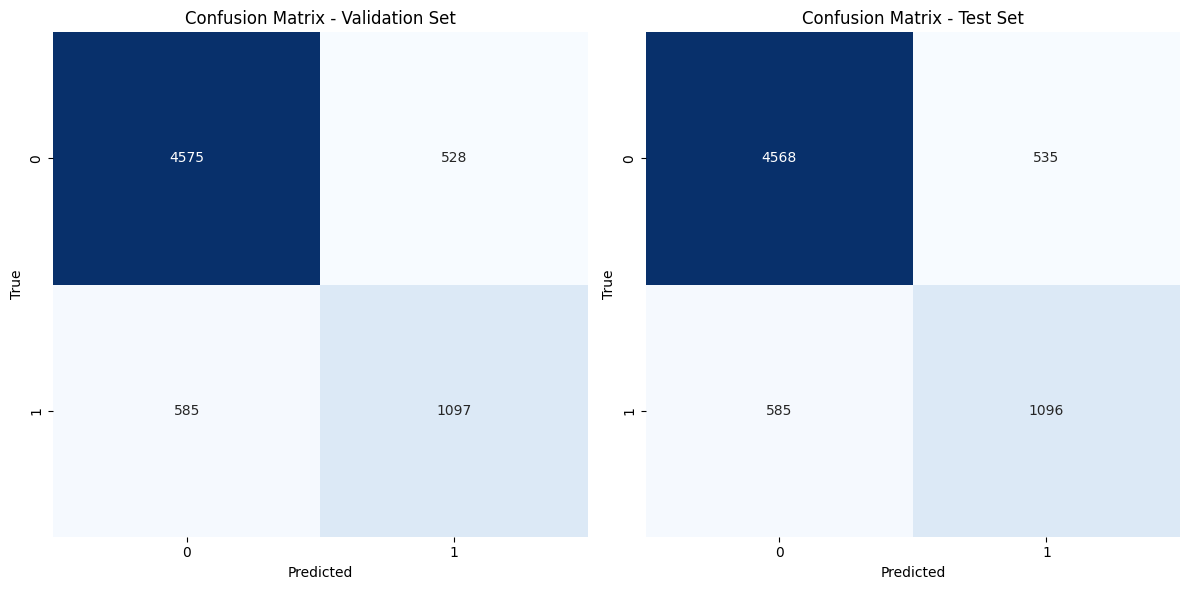

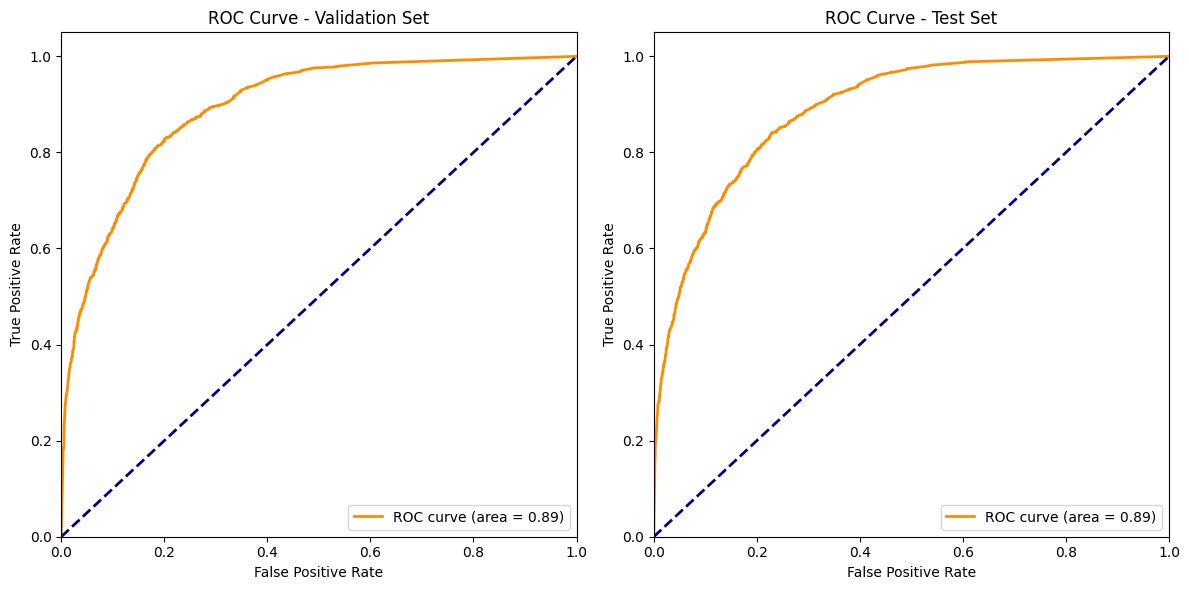

In [ ]:

# Create subplots to put the 2 img on a row
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Confusion Matrix for validation Set
cm_val_rf = confusion_matrix(y_val, y_val_pred_rf)
sns.heatmap(cm_val_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - Validation Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confusion Matrix - Test Set
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

#  ROC Curve for validation _ test Set

# Create subplots to put the 2 img on a row
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ROC Curve - Validation Set
fpr_val_rf, tpr_val_rf, _ = roc_curve(y_val, y_val_prob_rf)
roc_auc_val_rf = auc(fpr_val_rf, tpr_val_rf)
axes[0].plot(fpr_val_rf, tpr_val_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val_rf:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Validation Set')
axes[0].legend(loc="lower right")

# ROC Curve for the est Set
fpr_test_rf, tpr_test_rf, _ = roc_curve(y_test, y_test_prob_rf)
roc_auc_test_rf = auc(fpr_test_rf, tpr_test_rf)
axes[1].plot(fpr_test_rf, tpr_test_rf, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test_rf:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

##ANN in Keras

First result without tuning .doing oversampling and without early stopping or drop out

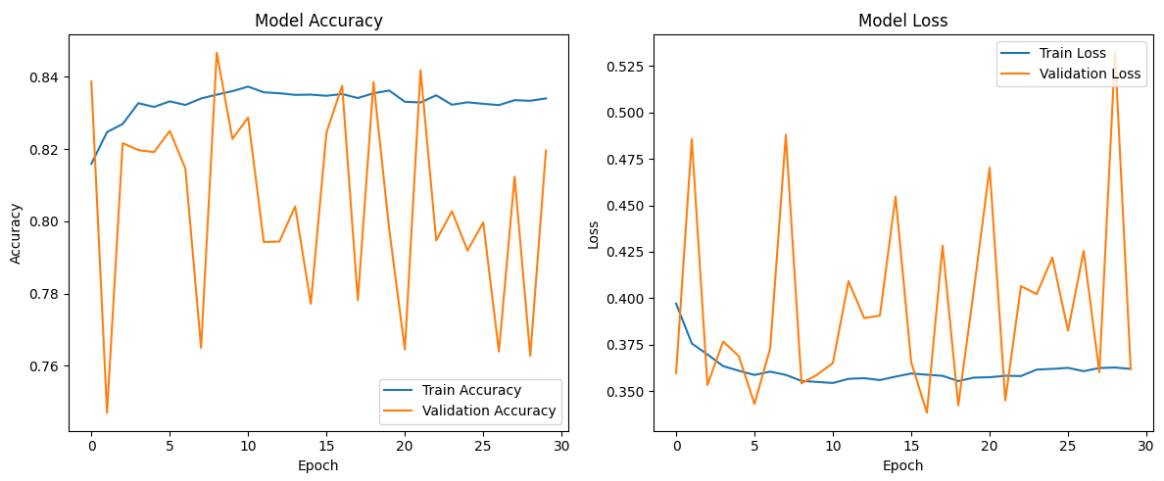

In [ ]:

# Initialize the ANN model
ann = Sequential()

# Input layer, 1 hidden layer, and output layer with Dropout
ann.add(Dense(64, input_dim=X_train_smote_scaled.shape[1], activation='relu'))
ann.add(Dropout(0.5))  # Dropout after input layer

ann.add(Dense(32, activation='relu'))
ann.add(Dropout(0.5))  # Dropout after hidden layer

ann.add(Dense(1, activation='sigmoid'))

# Compile the model with a lower learning rate
ann.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Implement Early Stopping to avoid overfitting and stop when validation loss does not improve
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the ANN model with a larger batch size and early stopping
history = ann.fit(X_train_smote_scaled, y_train_smote, validation_data=(X_val_scaled, y_val),
                  epochs=100, batch_size=64, callbacks=[early_stopping])  # Batch size changed to 64


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6154 - loss: 0.6781 - val_accuracy: 0.8027 - val_loss: 0.4302
Epoch 2/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7676 - loss: 0.4926 - val_accuracy: 0.8046 - val_loss: 0.3954
Epoch 3/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7914 - loss: 0.4506 - val_accuracy: 0.8010 - val_loss: 0.3904
Epoch 4/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7987 - loss: 0.4347 - val_accuracy: 0.7971 - val_loss: 0.3899
Epoch 5/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8075 - loss: 0.4178 - val_accuracy: 0.7956 - val_loss: 0.3879
Epoch 6/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8086 - loss: 0.4217 - val_accuracy: 0.7969 - val_loss: 0.3858
Epoch 7/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8079 - loss: 0.4208 - val_accuracy: 0.7969 - val_loss: 0.3856
Epoch 8/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8154 - loss: 0.4102 - val_acc

In [ ]:

# Evaluate the model on the validation set
val_loss, val_accuracy = ann.evaluate(X_val_scaled, y_val)
print(f"ANN (Validation Set) - Accuracy: {val_accuracy}")



213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8090 - loss: 0.3691
ANN (Validation Set) - Accuracy: 0.8072218298912048


In [ ]:

# Test set evaluation
test_loss, test_accuracy = ann.evaluate(X_test_scaled, y_test)
print(f"ANN (Test Set) - Accuracy: {test_accuracy}")


212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8050 - loss: 0.3632
ANN (Test Set) - Accuracy: 0.8045400977134705


213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


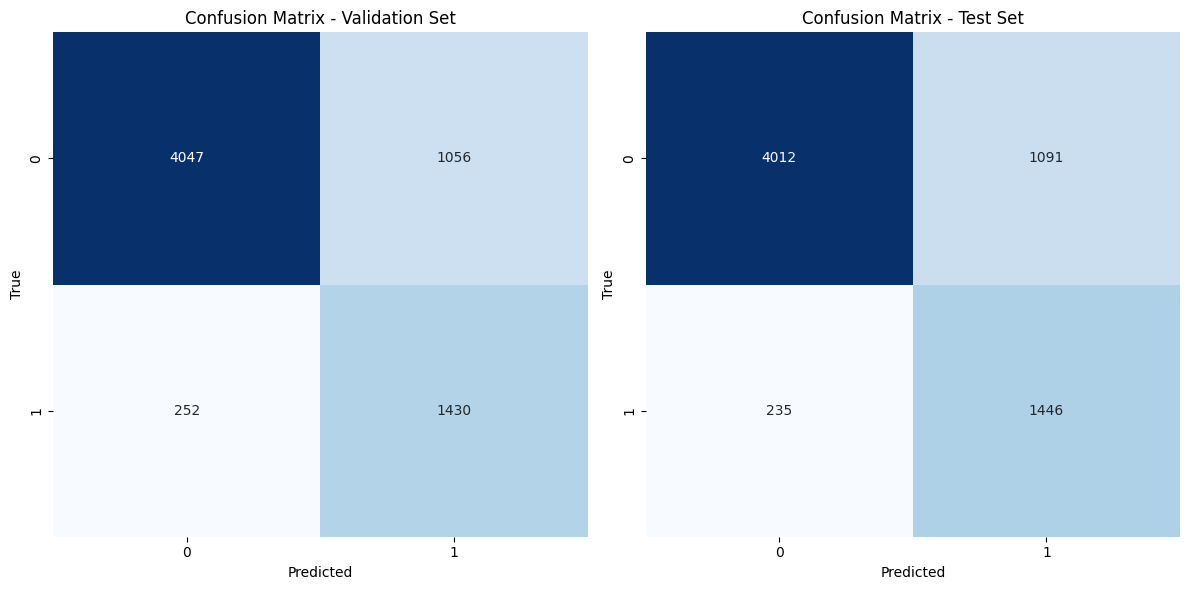

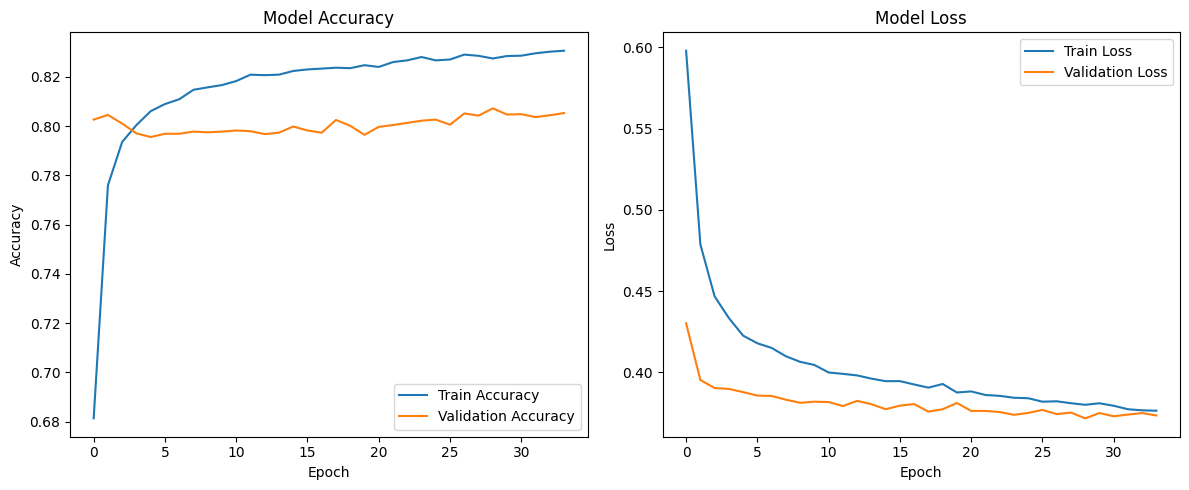

In [ ]:

# Confusion Matrix for Validation and Test Set

# Predict on validation and test sets
y_val_pred_ann = (ann.predict(X_val_scaled) > 0.5).astype(int)
y_test_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int)

# Confusion Matrix for Validation Set
cm_val_ann = confusion_matrix(y_val, y_val_pred_ann)
cm_test_ann = confusion_matrix(y_test, y_test_pred_ann)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Confusion Matrix - Validation Set
sns.heatmap(cm_val_ann, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - Validation Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confusion Matrix - Test Set
sns.heatmap(cm_test_ann, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# Learning Curve (Accuracy and Loss over epochs)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


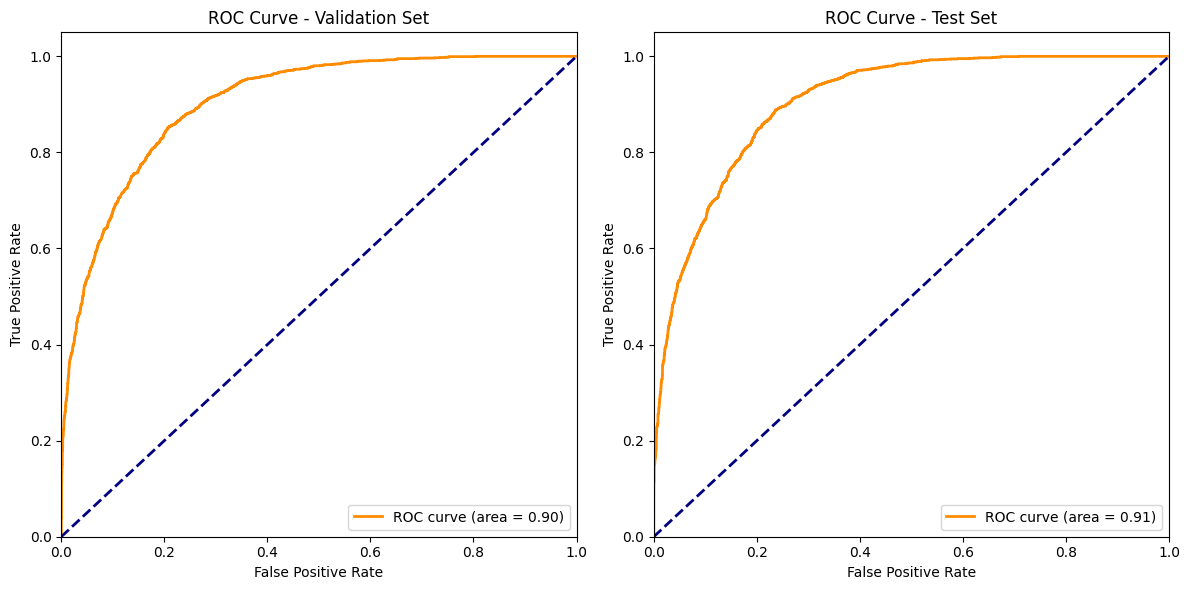

In [ ]:

# ROC Curve for Validation Set
y_val_prob_ann = ann.predict(X_val_scaled)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob_ann)
roc_auc_val = auc(fpr_val, tpr_val)

# ROC Curve for Test Set
y_test_prob_ann = ann.predict(X_test_scaled)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_ann)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC Curves for Validation and Test Sets side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ROC - Validation Set
axes[0].plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Validation Set')
axes[0].legend(loc="lower right")

# ROC - Test Set
axes[1].plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()



```
The best parameters was applied to the code below
```


```
Best Hyperparameters: {'units_input': 64, 'num_layers': 2, 'units_0': 128,

'activation': 'tanh', 'units_1': 128,

'learning_rate': 0.01, 'dropout_0': 0.1, 'dropout_1': 0.1}
```




Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


372/372 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8042 - loss: 0.4182 - val_accuracy: 0.7562 - val_loss: 0.4479
Epoch 2/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8239 - loss: 0.3783 - val_accuracy: 0.8112 - val_loss: 0.3754
Epoch 3/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8261 - loss: 0.3692 - val_accuracy: 0.7831 - val_loss: 0.4447
Epoch 4/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8327 - loss: 0.3604 - val_accuracy: 0.8063 - val_loss: 0.3713
Epoch 5/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8341 - loss: 0.3595 - val_accuracy: 0.8019 - val_loss: 0.3919
Epoch 6/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8345 - loss: 0.3550 - val_accuracy: 0.8195 - val_loss: 0.3794
Epoch 7/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8328 - loss: 0.3561 - val_accuracy: 0.7826 - val_loss: 0.4213
Epoch 8/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8380 - loss: 0.3517 - val_accuracy: 0.7960 - val_

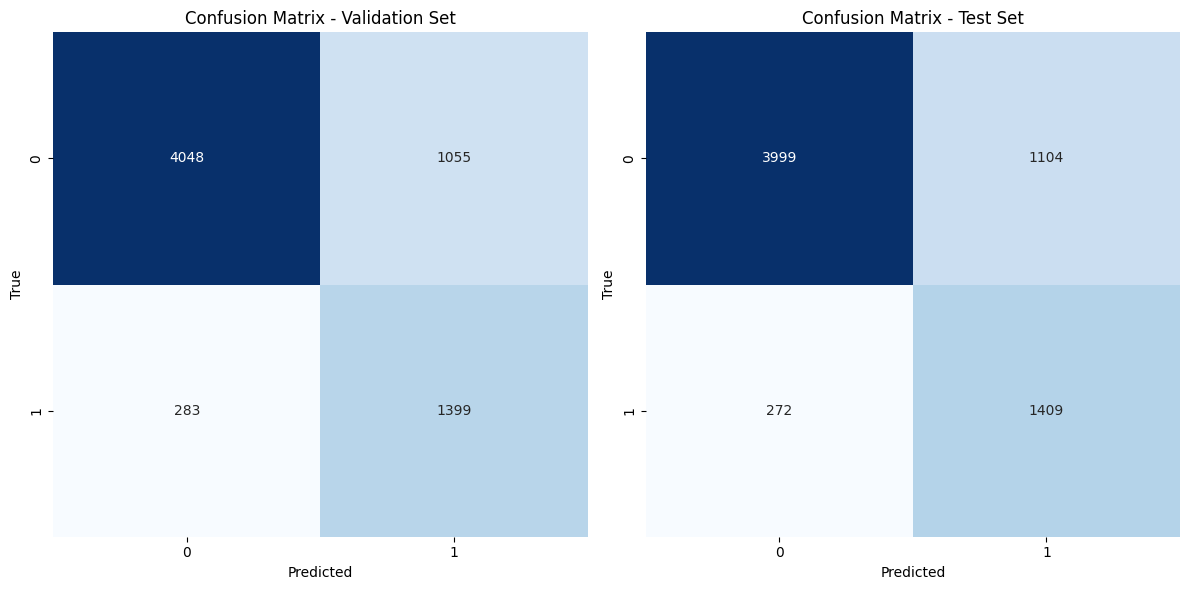

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


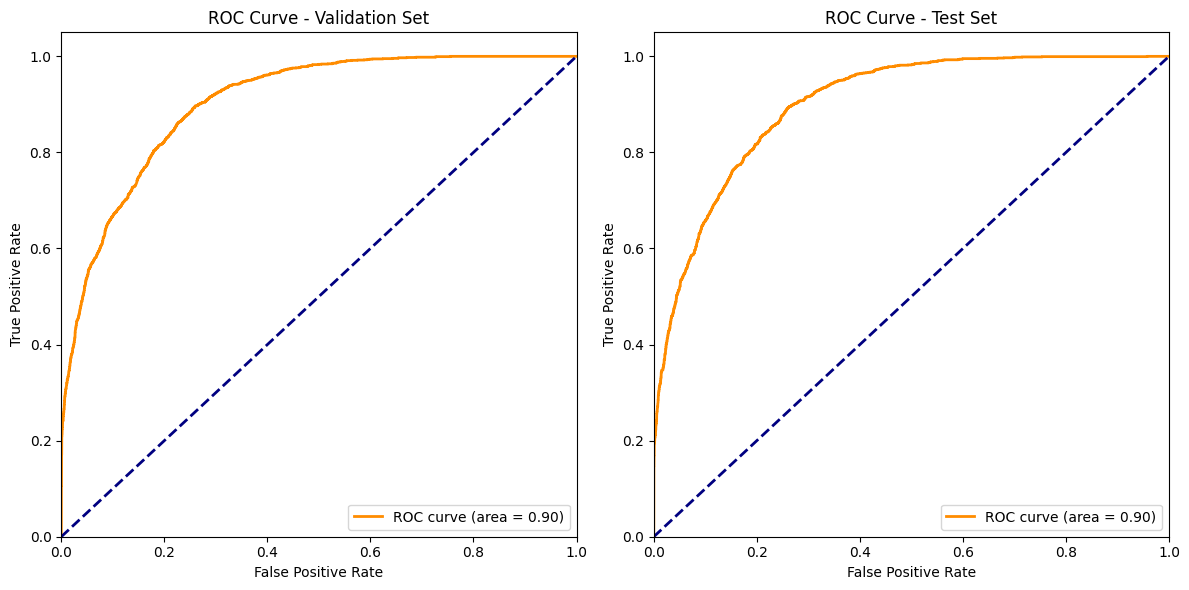

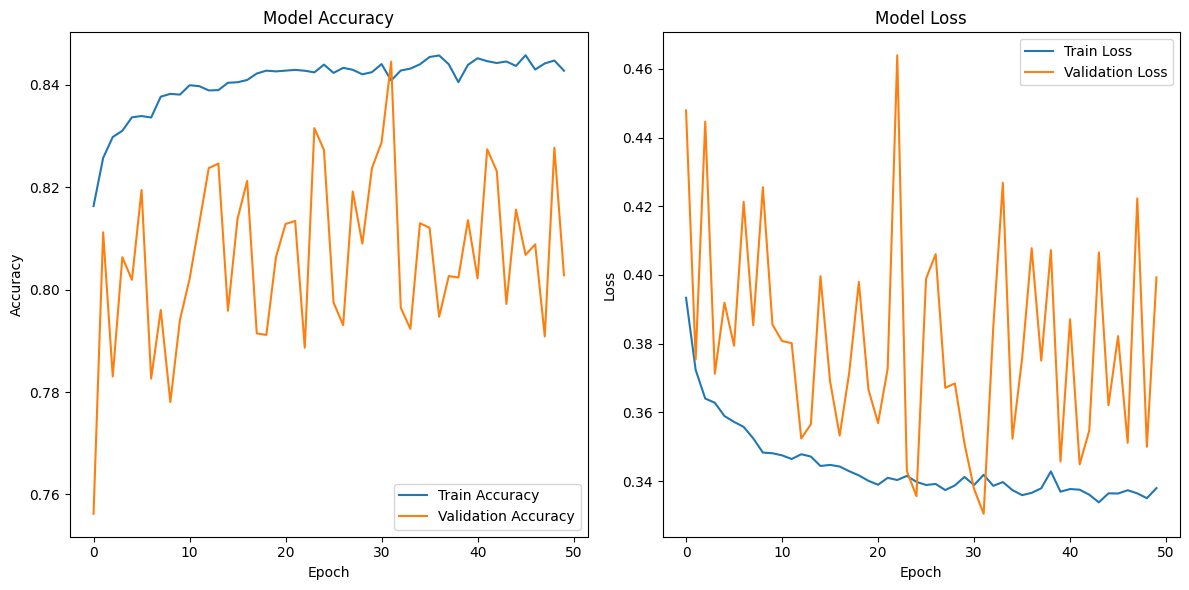

In [ ]:
# Manually assigning the best hyperparameters
ann = Sequential()

# Input layer
ann.add(Dense(64, input_dim=X_train_smote_scaled.shape[1], activation='tanh'))
ann.add(Dropout(0.1))  # Add dropout layer for regularization

# Hidden layers
ann.add(Dense(128, activation='tanh'))
ann.add(Dropout(0.1))
ann.add(Dense(128, activation='tanh'))

# Output layer
ann.add(Dense(1, activation='sigmoid'))

# Compile the model with the best learning rate
ann.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = ann.fit(X_train_smote_scaled, y_train_smote, validation_data=(X_val_scaled, y_val), epochs=50, batch_size=128)

# Evaluate on validation and test sets
val_loss, val_accuracy = ann.evaluate(X_val_scaled, y_val)
print(f"Tuned ANN (Validation Set) - Accuracy: {val_accuracy}")

test_loss, test_accuracy = ann.evaluate(X_test_scaled, y_test)
print(f"Tuned ANN (Test Set) - Accuracy: {test_accuracy}")

# Predictions on validation and test sets
y_val_pred_ann = (ann.predict(X_val_scaled) > 0.5).astype(int)
y_test_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int)

# --- Confusion Matrix for Validation and Test Set ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Confusion Matrix - Validation Set
cm_val_ann = confusion_matrix(y_val, y_val_pred_ann)
sns.heatmap(cm_val_ann, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix - Validation Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confusion Matrix - Test Set
cm_test_ann = confusion_matrix(y_test, y_test_pred_ann)
sns.heatmap(cm_test_ann, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# --- ROC Curve for Validation and Test Set ---
# Validation ROC curve
y_val_prob_ann = ann.predict(X_val_scaled)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob_ann)
roc_auc_val = auc(fpr_val, tpr_val)

plt.figure(figsize=(12, 6))

# ROC curve - Validation
plt.subplot(1, 2, 1)
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc="lower right")

# ROC Curve for Test Set
y_test_prob_ann = ann.predict(X_test_scaled)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_ann)
roc_auc_test = auc(fpr_test, tpr_test)

# ROC curve - Test
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- Learning Curves ---
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()





---



---



---


---



without early stopping or drop out
Best Hyperparameters: {'units_input': 64, 'num_layers': 2, 'units_0': 128, 'activation': 'tanh', 'units_1': 128, 'learning_rate': 0.01}



Tuned ANN (Validation Set) - Accuracy: 0.8144436478614807
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8137 - loss: 0.3580
Tuned ANN (Test Set) - Accuracy: 0.8145636916160583




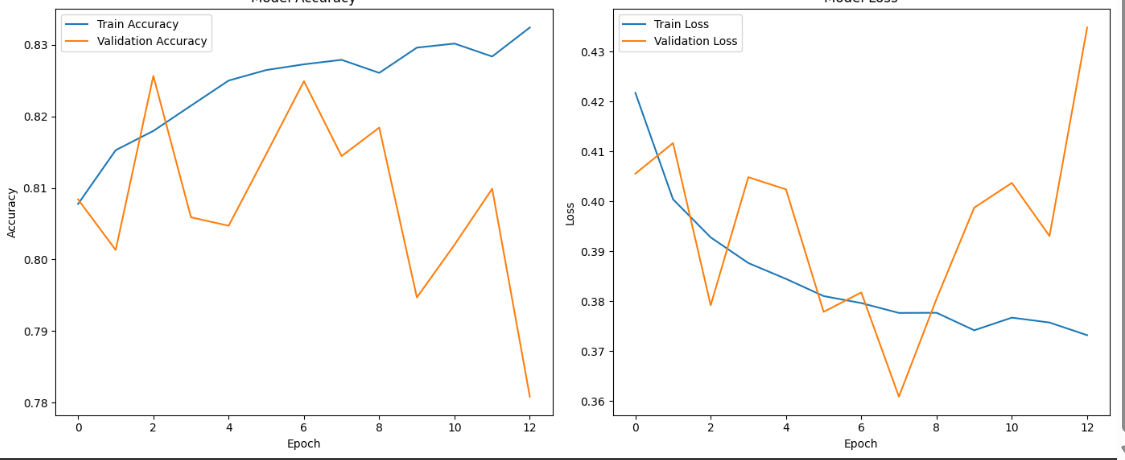